# News volatility prediction

Описание: Задача предсказания хаотичности и волатильности рынка перед выходом новости.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from warnings import filterwarnings
filterwarnings('ignore')

In [3]:
# Main libraries
import pandas as pd
import numpy as np
import pytz
from scipy.stats import entropy

# Plots
import matplotlib.pyplot as plt

# Progress bar
from tqdm.auto import tqdm
tqdm.pandas()

pd.set_option('display.max_columns', None)

# Обработка новостей

## Загрузка новостей

In [4]:
moscow_tz = pytz.timezone('Europe/Moscow')

In [5]:
PATH_TO_NEWS = r"../dataset/tradingview_economy_calendar/tw_calendar.csv"
news = pd.read_csv(PATH_TO_NEWS)
news = news[['date', 'currency', 'importance', 'title', 'indicator', 'country', 'category', 'actual', 'forecast', 'previous', 'comment', 'source', 'source_url', 'referenceDate', 'period', 'unit', 'scale']]
news.head()

,date,currency,importance,title,indicator,country,category,actual,forecast,previous,comment,source,source_url,referenceDate,period,unit,scale
0,2013-01-04T13:30:00.000Z,USD,1,Non Farm Payrolls,Non Farm Payrolls,US,lbr,NaN,NaN,NaN,Nonfarm payrolls is an employment report relea...,Bureau of Labour Statistics,http://www.bls.gov/,2012-12-31T00:00:00Z,DEC 2012,NaN,NaN
1,2013-01-04T13:30:00.000Z,USD,0,Unemployment Rate,Unemployment Rate,US,lbr,NaN,NaN,NaN,"In the United States, the unemployment rate me...",Bureau of Labour Statistics,http://www.bls.gov/,2012-12-31T00:00:00Z,DEC 2012,NaN,NaN
2,2013-01-06T13:00:00.000Z,EUR,-1,Inflation Rate MoM Flash,Inflation Rate Mom,DE,prce,NaN,NaN,0.2,"In Germany, the most important categories in t...",Federal Statistical Office,https://www.destatis.de,2013-12-31T00:00:00Z,Dec 2013,%,NaN
3,2013-01-17T09:30:00.000Z,GBP,-1,Retail Sales ex Fuel MoM,Retail Sales Ex Fuel,GB,cnsm,NaN,NaN,NaN,"In the United Kingdom, the Retail sales report...",Office for National Statistics,http://www.ons.gov.uk/,2013-12-31T00:00:00Z,Dec 2013,NaN,NaN
4,2013-01-17T09:30:00.000Z,GBP,-1,Retail Sales ex Fuel YoY,Retail Sales Ex Fuel,GB,cnsm,NaN,NaN,NaN,"In the United Kingdom, the Retail sales report...",Office for National Statistics,http://www.ons.gov.uk/,2013-12-31T00:00:00Z,Dec 2013,NaN,NaN


## Вытаскивание фичей

### Period extraction

In [6]:
def period_extraction(period):
    period = str(period).lower()
    monthes = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    monthes = [i.lower() for i in monthes]
    quarters = ['q1', 'q2', 'q3', 'q4']

    if any([i for i in monthes if i in period]):
        return 'M'
    
    elif any([i for i in quarters if i in period]):
        return 'Q'
    
    else:
        return None

In [7]:
news['period'] = news['period'].astype(str).apply(period_extraction)

### Категория новостей по группам

In [8]:
NEWS_CLASSES = [
    "MONETARY_POLICY",      # решения ЦБ
    "CB_SPEECH",            # речи ЦБ
    "INFLATION",            # инфляция
    "LABOR_MARKET",         # рынок труда
    "ECONOMIC_ACTIVITY",    # рост / производство
    "SENTIMENT",            # опросы / ожидания
    "CONSUMER_HOUSING",     # потребитель / жильё
    "TRADE_FINANCE",        # торговля / деньги / финансы
    "COMMODITIES"           # нефть / газ / сырьё
]

In [9]:
MONETARY_POLICY = [
    "rate", "policy", "monetary", "fomc", "mpc", "meeting",
    "minutes", "statement", "votes",
    "asset purchase", "purchase facility", "refinancing",
    "cash rate", "bank rate", "official cash",
    "fed", "ecb", "boe", "boj", "rba", "rbnz", "boc", "snb",
    "overnight rate", "federal funds", "funds rate",
    "interest rate", "deposit interest rate", "loan prime rate", 
    "central bank balance sheet"
]

CB_SPEECH = [
    "speaks", "press conference", "press",
    "chair", "president", "gov",
    "powell", "lagarde", "bailey", "kuroda", "draghi",
    "yellen", "carney", "bullard", "waller", "kashkari",
    "member"
]

INFLATION = [
    "cpi", "core cpi", 
    "ppi", "core ppi",
    "pce", "core pce",
    "inflation rate", "core inflation rate",
    "consumer price index",
    "harmonized inflation rate", "pce price index",
    "inflation", "price index", "prices",
    "median cpi", "trimmed cpi",
    "inflation expectations", "tokyo cpi"
]

LABOR_MARKET = [
    "employment", "unemployment", "job", "claims",
    "employment change", "averate hourly earnings",
    "non farm", "nonfarm", "payrolls",
    "adp", "jolts", "job openings", "jobless",
    "labor", "labor force", "labor market",
    "earnings", "hourly earnings",
    "job cuts", "challenger"
]

GDP = [
    "gdp", "gdp growth rate", "gdp annual",
    "growth annualized", "gdp qoq", "monthly gdp"
]

ECONOMIC_ACTIVITY = [
    "manufacturing", "services", 
    "output", "capacity", "utilization",
    "productivity", "investment"
]

SENTIMENT = [
    "pmi", "ism", "confidence", "sentiment",
    "ifo", "zew", "gfk", "nfib", "philly",
    "survey", "optimism", "barometer",
    "expectations", "watchers"
]

CONSUMER_HOUSING = [
    "retail", "sales", "consumer",
    "housing", "home", "mortgage",
    "building", "permits", "starts",
    "house price", "hpi", 
    "personal spending", "personal income",
    "new home sales", "existing home sales", 
    "building permits", "housing starts"
]

MANUFACTORING = [
    "industrial", "production",
    "orders", "factory orders",
    "goods"
]

TRADE_FINANCE = [
    "trade", "balance", "current account",
    "budget", "borrowing", "credit",
    "money supply", "m2", "m3",
    "lending", "loans", "reserves",
    "foreign", "currency"
]

COMMODITIES = [
    "oil", "crude", "gas",
    "inventories", "storage",
    "opec", "commodity prices"
]

BONDS = [
    '10y bond yield',
    'bond', 'bund ', 'yields',
    'yield', 'bonds', 
    'bond yield', '2y note yield'
]

In [10]:
CLASS_KEYWORDS = {
    "MONETARY_POLICY": MONETARY_POLICY,
    "CB_SPEECH": CB_SPEECH,
    "INFLATION": INFLATION,
    "LABOR_MARKET": LABOR_MARKET,
    "GDP": GDP,
    "ECONOMIC_ACTIVITY": ECONOMIC_ACTIVITY,
    "SENTIMENT": SENTIMENT,
    "CONSUMER_HOUSING": CONSUMER_HOUSING,
    "MANUFACTORING": MANUFACTORING,
    "TRADE_FINANCE": TRADE_FINANCE,
    "COMMODITIES": COMMODITIES,
    "BONDS": BONDS
}

In [11]:
def classify_news(title: str):
    title = str(title).lower()
    scores = {}

    for cls, keywords in CLASS_KEYWORDS.items():
        scores[cls] = sum(1 for k in keywords if k in title)

    if max(scores.values()) == 0:
        return "OTHER"

    return max(scores, key=scores.get)

In [12]:
news['class'] = news['indicator'].astype(str).progress_apply(classify_news)

  0%|          | 0/91765 [00:00<?, ?it/s]

100%|██████████| 91765/91765 [00:01<00:00, 49225.17it/s]


In [13]:
news['class'].value_counts()  # title

class
OTHER                15149
INFLATION            13383
MONETARY_POLICY      12164
ECONOMIC_ACTIVITY     8380
CONSUMER_HOUSING      7838
SENTIMENT             6794
BONDS                 6297
LABOR_MARKET          6196
MANUFACTORING         4341
COMMODITIES           4280
TRADE_FINANCE         3629
GDP                   2063
CB_SPEECH             1251
Name: count, dtype: int64

### Конкретные события

In [14]:
# def get_major_event_type(title: str) -> str:
#     t = title.lower()

#     if any([i for i in ["non farm", "nonfarm", "payrolls"] if i in t]):
#         return "NFP"
#     if "interest rate" in t:
#         return "INTEREST_RATE"
#     if "cpi" in t and "core" in t:
#         return "CORE_CPI"
#     if "cpi" in t:
#         return "CPI"
#     if "gdp" in t:
#         return "GDP"
#     if "pmi" in t and "manufacturing" in t:
#         return "PMI_MANUFACTURING"
#     if "pmi" in t and "services" in t:
#         return "PMI_SERVICES"
#     if "retail" in t:
#         return "RETAIL_SALES"
#     if "unemployment" in t and "rate" in t:
#         return "UNEMPLOYMENT_RATE"
#     if 'average hourly earnings' in t:
#         return "AVERAGE_HOURLY_EARNINGS"

#     return "OTHER"

In [15]:
def get_specific_event_type(title: str) -> str:
    t = title.lower()

    if any([i for i in ["non farm", "nonfarm", "payrolls"] if i in t]):
        return "NFP"
    if "interest rate" in t:
        return "INTEREST_RATE"
    if "cpi" in t and "core" in t:
        return "CPI_CORE"
    if "cpi" in t:
        return "CPI"
    if "gdp" in t:
        return "GDP"
    if "pmi" in t and 'manufacturing' in t:
        return "PMI_MANUFACTURING"
    if "pmi" in t and 'services' in t:
        return "PMI_SERVICES"
    if "retail" in t:
        return "RETAIL_SALES"
    
    return "OTHER"

In [16]:
news['event_type'] = news['indicator'].apply(get_specific_event_type)

In [17]:
dummy_events = pd.get_dummies(news['event_type'], prefix='e').astype(int).drop(['e_OTHER', 'e_CPI_CORE'], axis=1)
dummy_events

,e_CPI,e_GDP,e_INTEREST_RATE,e_NFP,e_PMI_MANUFACTURING,e_PMI_SERVICES,e_RETAIL_SALES
0,0,0,0,1,0,0,0
1,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0
3,0,0,0,0,0,0,1
4,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...
91760,0,0,0,0,0,0,0
91761,0,0,0,0,0,0,0
91762,0,0,0,0,0,0,0
91763,0,0,0,0,0,0,0


In [18]:
news = pd.concat([news, dummy_events], axis=1)
news.head()

,date,currency,importance,title,indicator,country,category,actual,forecast,previous,comment,source,source_url,referenceDate,period,unit,scale,class,event_type,e_CPI,e_GDP,e_INTEREST_RATE,e_NFP,e_PMI_MANUFACTURING,e_PMI_SERVICES,e_RETAIL_SALES
0,2013-01-04T13:30:00.000Z,USD,1,Non Farm Payrolls,Non Farm Payrolls,US,lbr,NaN,NaN,NaN,Nonfarm payrolls is an employment report relea...,Bureau of Labour Statistics,http://www.bls.gov/,2012-12-31T00:00:00Z,M,NaN,NaN,LABOR_MARKET,NFP,0,0,0,1,0,0,0
1,2013-01-04T13:30:00.000Z,USD,0,Unemployment Rate,Unemployment Rate,US,lbr,NaN,NaN,NaN,"In the United States, the unemployment rate me...",Bureau of Labour Statistics,http://www.bls.gov/,2012-12-31T00:00:00Z,M,NaN,NaN,LABOR_MARKET,OTHER,0,0,0,0,0,0,0
2,2013-01-06T13:00:00.000Z,EUR,-1,Inflation Rate MoM Flash,Inflation Rate Mom,DE,prce,NaN,NaN,0.2,"In Germany, the most important categories in t...",Federal Statistical Office,https://www.destatis.de,2013-12-31T00:00:00Z,M,%,NaN,INFLATION,OTHER,0,0,0,0,0,0,0
3,2013-01-17T09:30:00.000Z,GBP,-1,Retail Sales ex Fuel MoM,Retail Sales Ex Fuel,GB,cnsm,NaN,NaN,NaN,"In the United Kingdom, the Retail sales report...",Office for National Statistics,http://www.ons.gov.uk/,2013-12-31T00:00:00Z,M,NaN,NaN,CONSUMER_HOUSING,RETAIL_SALES,0,0,0,0,0,0,1
4,2013-01-17T09:30:00.000Z,GBP,-1,Retail Sales ex Fuel YoY,Retail Sales Ex Fuel,GB,cnsm,NaN,NaN,NaN,"In the United Kingdom, the Retail sales report...",Office for National Statistics,http://www.ons.gov.uk/,2013-12-31T00:00:00Z,M,NaN,NaN,CONSUMER_HOUSING,RETAIL_SALES,0,0,0,0,0,0,1


### Категории

In [20]:
dummy_categories = pd.get_dummies(news['class'], prefix='class').drop(['class_' + i for i in ['OTHER']], axis=1).astype(int)
dummy_categories.head()

,class_BONDS,class_CB_SPEECH,class_COMMODITIES,class_CONSUMER_HOUSING,class_ECONOMIC_ACTIVITY,class_GDP,class_INFLATION,class_LABOR_MARKET,class_MANUFACTORING,class_MONETARY_POLICY,class_SENTIMENT,class_TRADE_FINANCE
0,0,0,0,0,0,0,0,1,0,0,0,0
1,0,0,0,0,0,0,0,1,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,0,0
3,0,0,0,1,0,0,0,0,0,0,0,0
4,0,0,0,1,0,0,0,0,0,0,0,0


In [21]:
news = pd.concat([news, dummy_categories], axis=1)
news.head()

,date,currency,importance,title,indicator,country,category,actual,forecast,previous,comment,source,source_url,referenceDate,period,unit,scale,class,event_type,e_CPI,e_GDP,e_INTEREST_RATE,e_NFP,e_PMI_MANUFACTURING,e_PMI_SERVICES,e_RETAIL_SALES,class_BONDS,class_CB_SPEECH,class_COMMODITIES,class_CONSUMER_HOUSING,class_ECONOMIC_ACTIVITY,class_GDP,class_INFLATION,class_LABOR_MARKET,class_MANUFACTORING,class_MONETARY_POLICY,class_SENTIMENT,class_TRADE_FINANCE
0,2013-01-04T13:30:00.000Z,USD,1,Non Farm Payrolls,Non Farm Payrolls,US,lbr,NaN,NaN,NaN,Nonfarm payrolls is an employment report relea...,Bureau of Labour Statistics,http://www.bls.gov/,2012-12-31T00:00:00Z,M,NaN,NaN,LABOR_MARKET,NFP,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
1,2013-01-04T13:30:00.000Z,USD,0,Unemployment Rate,Unemployment Rate,US,lbr,NaN,NaN,NaN,"In the United States, the unemployment rate me...",Bureau of Labour Statistics,http://www.bls.gov/,2012-12-31T00:00:00Z,M,NaN,NaN,LABOR_MARKET,OTHER,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
2,2013-01-06T13:00:00.000Z,EUR,-1,Inflation Rate MoM Flash,Inflation Rate Mom,DE,prce,NaN,NaN,0.2,"In Germany, the most important categories in t...",Federal Statistical Office,https://www.destatis.de,2013-12-31T00:00:00Z,M,%,NaN,INFLATION,OTHER,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
3,2013-01-17T09:30:00.000Z,GBP,-1,Retail Sales ex Fuel MoM,Retail Sales Ex Fuel,GB,cnsm,NaN,NaN,NaN,"In the United Kingdom, the Retail sales report...",Office for National Statistics,http://www.ons.gov.uk/,2013-12-31T00:00:00Z,M,NaN,NaN,CONSUMER_HOUSING,RETAIL_SALES,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0
4,2013-01-17T09:30:00.000Z,GBP,-1,Retail Sales ex Fuel YoY,Retail Sales Ex Fuel,GB,cnsm,NaN,NaN,NaN,"In the United Kingdom, the Retail sales report...",Office for National Statistics,http://www.ons.gov.uk/,2013-12-31T00:00:00Z,M,NaN,NaN,CONSUMER_HOUSING,RETAIL_SALES,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0


In [140]:
dummy_period = pd.get_dummies(news['period'], prefix='period')
dummy_period

,period_M,period_Q
0,True,False
1,True,False
2,True,False
3,True,False
4,True,False
...,...,...
91760,True,False
91761,False,False
91762,True,False
91763,True,False


In [142]:
news = pd.concat([news, dummy_period], axis=1)

### Добавление тир категории новости

In [22]:
def classify_event_tier(row) -> int:
    """Return the tier of event.
    1 - max importance;
    2 - high importance;
    3 - avg importance;
    4 - low importance"""
    if row['event_type'] != 'OTHER':
        return 4
    else:
        indicator = str(row['indicator']).lower()
        if any([i for i in CONSUMER_HOUSING if i in indicator]):
            return 3
        elif any([i for i in MANUFACTORING if i in indicator]):
            return 3
        elif any([i for i in BONDS if i in indicator]):
            return 3
        else:
            tier3_list = ['import', 'export', 'loans', 'credit', 'balance', 'account', 'inventories']
            if any([i for i in tier3_list if i in indicator]):
                return 2
            else:
                return 1

In [23]:
news['event_tier'] = news.apply(classify_event_tier, axis=1)

In [24]:
news.head()

,date,currency,importance,title,indicator,country,category,actual,forecast,previous,comment,source,source_url,referenceDate,period,unit,scale,class,event_type,e_CPI,e_GDP,e_INTEREST_RATE,e_NFP,e_PMI_MANUFACTURING,e_PMI_SERVICES,e_RETAIL_SALES,class_BONDS,class_CB_SPEECH,class_COMMODITIES,class_CONSUMER_HOUSING,class_ECONOMIC_ACTIVITY,class_GDP,class_INFLATION,class_LABOR_MARKET,class_MANUFACTORING,class_MONETARY_POLICY,class_SENTIMENT,class_TRADE_FINANCE,event_tier
0,2013-01-04T13:30:00.000Z,USD,1,Non Farm Payrolls,Non Farm Payrolls,US,lbr,NaN,NaN,NaN,Nonfarm payrolls is an employment report relea...,Bureau of Labour Statistics,http://www.bls.gov/,2012-12-31T00:00:00Z,M,NaN,NaN,LABOR_MARKET,NFP,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,4
1,2013-01-04T13:30:00.000Z,USD,0,Unemployment Rate,Unemployment Rate,US,lbr,NaN,NaN,NaN,"In the United States, the unemployment rate me...",Bureau of Labour Statistics,http://www.bls.gov/,2012-12-31T00:00:00Z,M,NaN,NaN,LABOR_MARKET,OTHER,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1
2,2013-01-06T13:00:00.000Z,EUR,-1,Inflation Rate MoM Flash,Inflation Rate Mom,DE,prce,NaN,NaN,0.2,"In Germany, the most important categories in t...",Federal Statistical Office,https://www.destatis.de,2013-12-31T00:00:00Z,M,%,NaN,INFLATION,OTHER,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1
3,2013-01-17T09:30:00.000Z,GBP,-1,Retail Sales ex Fuel MoM,Retail Sales Ex Fuel,GB,cnsm,NaN,NaN,NaN,"In the United Kingdom, the Retail sales report...",Office for National Statistics,http://www.ons.gov.uk/,2013-12-31T00:00:00Z,M,NaN,NaN,CONSUMER_HOUSING,RETAIL_SALES,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,4
4,2013-01-17T09:30:00.000Z,GBP,-1,Retail Sales ex Fuel YoY,Retail Sales Ex Fuel,GB,cnsm,NaN,NaN,NaN,"In the United Kingdom, the Retail sales report...",Office for National Statistics,http://www.ons.gov.uk/,2013-12-31T00:00:00Z,M,NaN,NaN,CONSUMER_HOUSING,RETAIL_SALES,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,4


In [45]:
# KEY_EVENTS = {
#     "NFP", "CPI", "CORE_CPI", "PCE", "FOMC_RATE", "FOMC_PRES_CONF",
#     "PMI_MANUFACTURING", "PMI_SERVICES", "GDP"
# }

# news["is_key_event"] = news["event_type"].isin(KEY_EVENTS)
news['is_key_event'] = news['event_type'].apply(lambda x: 1 if x != 'OTHER' else 0)

In [28]:
EVENT_WEIGHTS = {
    "NFP": 5,
    "CPI": 5,
    "CORE_CPI": 5,
    "PCE": 4,
    "FOMC_RATE": 5,
    "FOMC_PRES_CONF": 4,
    "PMI_MANUFACTURING": 3,
    "PMI_SERVICES": 3,
    "GDP": 3,
    "RETAIL_SALES": 2,
    "OTHER": 1
}

news["event_weight"] = news["event_type"].map(EVENT_WEIGHTS)

In [29]:
news.head(5)

,date,currency,importance,title,indicator,country,category,actual,forecast,previous,comment,source,source_url,referenceDate,period,unit,scale,class,event_type,e_CPI,e_GDP,e_INTEREST_RATE,e_NFP,e_PMI_MANUFACTURING,e_PMI_SERVICES,e_RETAIL_SALES,class_BONDS,class_CB_SPEECH,class_COMMODITIES,class_CONSUMER_HOUSING,class_ECONOMIC_ACTIVITY,class_GDP,class_INFLATION,class_LABOR_MARKET,class_MANUFACTORING,class_MONETARY_POLICY,class_SENTIMENT,class_TRADE_FINANCE,event_tier,is_key_event,event_weight
0,2013-01-04T13:30:00.000Z,USD,1,Non Farm Payrolls,Non Farm Payrolls,US,lbr,NaN,NaN,NaN,Nonfarm payrolls is an employment report relea...,Bureau of Labour Statistics,http://www.bls.gov/,2012-12-31T00:00:00Z,M,NaN,NaN,LABOR_MARKET,NFP,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,4,True,5.0
1,2013-01-04T13:30:00.000Z,USD,0,Unemployment Rate,Unemployment Rate,US,lbr,NaN,NaN,NaN,"In the United States, the unemployment rate me...",Bureau of Labour Statistics,http://www.bls.gov/,2012-12-31T00:00:00Z,M,NaN,NaN,LABOR_MARKET,OTHER,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,False,1.0
2,2013-01-06T13:00:00.000Z,EUR,-1,Inflation Rate MoM Flash,Inflation Rate Mom,DE,prce,NaN,NaN,0.2,"In Germany, the most important categories in t...",Federal Statistical Office,https://www.destatis.de,2013-12-31T00:00:00Z,M,%,NaN,INFLATION,OTHER,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,False,1.0
3,2013-01-17T09:30:00.000Z,GBP,-1,Retail Sales ex Fuel MoM,Retail Sales Ex Fuel,GB,cnsm,NaN,NaN,NaN,"In the United Kingdom, the Retail sales report...",Office for National Statistics,http://www.ons.gov.uk/,2013-12-31T00:00:00Z,M,NaN,NaN,CONSUMER_HOUSING,RETAIL_SALES,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,4,False,2.0
4,2013-01-17T09:30:00.000Z,GBP,-1,Retail Sales ex Fuel YoY,Retail Sales Ex Fuel,GB,cnsm,NaN,NaN,NaN,"In the United Kingdom, the Retail sales report...",Office for National Statistics,http://www.ons.gov.uk/,2013-12-31T00:00:00Z,M,NaN,NaN,CONSUMER_HOUSING,RETAIL_SALES,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,4,False,2.0


In [30]:
news['impact_rank'] = news['importance'] + 1

### Построение агрегированных новостей для МЛ модели

In [31]:
news.head(5)

,date,currency,importance,title,indicator,country,category,actual,forecast,previous,comment,source,source_url,referenceDate,period,unit,scale,class,event_type,e_CPI,e_GDP,e_INTEREST_RATE,e_NFP,e_PMI_MANUFACTURING,e_PMI_SERVICES,e_RETAIL_SALES,class_BONDS,class_CB_SPEECH,class_COMMODITIES,class_CONSUMER_HOUSING,class_ECONOMIC_ACTIVITY,class_GDP,class_INFLATION,class_LABOR_MARKET,class_MANUFACTORING,class_MONETARY_POLICY,class_SENTIMENT,class_TRADE_FINANCE,event_tier,is_key_event,event_weight,impact_rank
0,2013-01-04T13:30:00.000Z,USD,1,Non Farm Payrolls,Non Farm Payrolls,US,lbr,NaN,NaN,NaN,Nonfarm payrolls is an employment report relea...,Bureau of Labour Statistics,http://www.bls.gov/,2012-12-31T00:00:00Z,M,NaN,NaN,LABOR_MARKET,NFP,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,4,True,5.0,2
1,2013-01-04T13:30:00.000Z,USD,0,Unemployment Rate,Unemployment Rate,US,lbr,NaN,NaN,NaN,"In the United States, the unemployment rate me...",Bureau of Labour Statistics,http://www.bls.gov/,2012-12-31T00:00:00Z,M,NaN,NaN,LABOR_MARKET,OTHER,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,False,1.0,1
2,2013-01-06T13:00:00.000Z,EUR,-1,Inflation Rate MoM Flash,Inflation Rate Mom,DE,prce,NaN,NaN,0.2,"In Germany, the most important categories in t...",Federal Statistical Office,https://www.destatis.de,2013-12-31T00:00:00Z,M,%,NaN,INFLATION,OTHER,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,False,1.0,0
3,2013-01-17T09:30:00.000Z,GBP,-1,Retail Sales ex Fuel MoM,Retail Sales Ex Fuel,GB,cnsm,NaN,NaN,NaN,"In the United Kingdom, the Retail sales report...",Office for National Statistics,http://www.ons.gov.uk/,2013-12-31T00:00:00Z,M,NaN,NaN,CONSUMER_HOUSING,RETAIL_SALES,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,4,False,2.0,0
4,2013-01-17T09:30:00.000Z,GBP,-1,Retail Sales ex Fuel YoY,Retail Sales Ex Fuel,GB,cnsm,NaN,NaN,NaN,"In the United Kingdom, the Retail sales report...",Office for National Statistics,http://www.ons.gov.uk/,2013-12-31T00:00:00Z,M,NaN,NaN,CONSUMER_HOUSING,RETAIL_SALES,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,4,False,2.0,0


In [32]:
news['utc_dt'] = pd.to_datetime(news['date'], utc=True).dt.tz_convert(moscow_tz)

In [33]:
def floor_or_ceil(x: str):
    """
    Если значения минут ближе к 30 или 00, значит округляем в большую сторону, иначе в меньшую.
    """
    x_dt = pd.to_datetime(x)
    if (29 >= x_dt.minute >= 20) or (59 >= x_dt.minute >= 50):  # TODO: May be change to last 5 minutes (20 -> 25 and 50 -> 55)
        return x_dt.ceil('30min', ambiguous='NaT', nonexistent='shift_forward')
    else:
        return x_dt.floor('30min')

In [34]:
news['custom_event_time'] = news['utc_dt'].progress_apply(floor_or_ceil)

  0%|          | 0/91765 [00:00<?, ?it/s]

100%|██████████| 91765/91765 [00:19<00:00, 4643.81it/s]


In [35]:
# news_classes = pd.get_dummies(news['class']).drop('OTHER', axis=1).astype(int)
# news_classes = pd.concat([news, news_classes], axis=1)
# news_classes.head()

In [36]:
# news_events = pd.get_dummies(news_classes['event_type'], prefix='IS').drop(['IS_OTHER', 'IS_FOMC_PRES_CONF', 'IS_CORE_CPI'], axis=1).astype(int)
# news_events = pd.concat([news_classes, news_events], axis=1)
# news_events.head()

In [37]:
news.columns

Index(['date', 'currency', 'importance', 'title', 'indicator', 'country',
       'category', 'actual', 'forecast', 'previous', 'comment', 'source',
       'source_url', 'referenceDate', 'period', 'unit', 'scale', 'class',
       'event_type', 'e_CPI', 'e_GDP', 'e_INTEREST_RATE', 'e_NFP',
       'e_PMI_MANUFACTURING', 'e_PMI_SERVICES', 'e_RETAIL_SALES',
       'class_BONDS', 'class_CB_SPEECH', 'class_COMMODITIES',
       'class_CONSUMER_HOUSING', 'class_ECONOMIC_ACTIVITY', 'class_GDP',
       'class_INFLATION', 'class_LABOR_MARKET', 'class_MANUFACTORING',
       'class_MONETARY_POLICY', 'class_SENTIMENT', 'class_TRADE_FINANCE',
       'event_tier', 'is_key_event', 'event_weight', 'impact_rank', 'utc_dt',
       'custom_event_time'],
      dtype='str')

In [ ]:
dominant_event = (
        news.groupby(['customcustom_event_time_event_time', "event_type"])
          .size()
          .reset_index(name="cnt")
          .sort_values(['custom_event_time', "cnt"], ascending=[True, False])
          .drop_duplicates('custom_event_time')
          .set_index('custom_event_time')[["event_type"]]
          .rename(columns={"event_type": "dominant_event_type"})
    )
dominant_event

,dominant_event_type
custom_event_time,
2013-01-04 17:30:00+04:00,NFP
2013-01-06 17:00:00+04:00,OTHER
2013-01-17 13:30:00+04:00,RETAIL_SALES
2013-01-23 13:30:00+04:00,INTEREST_RATE
2013-01-25 17:30:00+04:00,OTHER
...,...
2025-12-31 16:30:00+03:00,OTHER
2025-12-31 18:00:00+03:00,OTHER
2025-12-31 18:30:00+03:00,OTHER


In [88]:
dominant_event = (
        news.groupby(['custom_event_time', 'event_type', 'event_weight']) \
        .size()
        .reset_index(name="cnt")
        .sort_values(['custom_event_time', "cnt"], ascending=[True, False])
        .drop_duplicates('custom_event_time')
        .set_index('custom_event_time')[["event_type"]]
        .rename(columns={"event_type": "dominant_event_type"})
    )
dominant_event

,dominant_event_type
custom_event_time,
2013-01-04 17:30:00+04:00,NFP
2013-01-06 17:00:00+04:00,OTHER
2013-01-17 13:30:00+04:00,RETAIL_SALES
2013-01-23 13:30:00+04:00,OTHER
2013-01-25 17:30:00+04:00,OTHER
...,...
2025-12-31 16:30:00+03:00,OTHER
2025-12-31 18:00:00+03:00,OTHER
2025-12-31 18:30:00+03:00,OTHER


In [143]:
def build_hour_features(
    news_df: pd.DataFrame,
    key_event_types: list[str] | None = None,
    event_time_column: str = 'custom_event_time'
) -> pd.DataFrame:
    """
    Build hour-level aggregated features from event-level news dataframe.

    Parameters
    ----------
    news_df : pd.DataFrame
        Event-level news data. Must contain:
        ['event_hour', 'event_type', 'news_class',
         'impact_rank', 'is_key_event', 'event_weight']

    key_event_types : list[str], optional
        List of key event types to build presence flags for
        (e.g. ['NFP', 'CPI', 'PMI_MANUFACTURING']).
        If None, inferred from is_key_event == True.

    Returns
    -------
    pd.DataFrame
        Hour-level feature table indexed by event_hour.
    """

    df = news_df.copy()

    # -----------------------------
    # 1. BASIC COUNTS & INTENSITY
    # -----------------------------
    agg = df.groupby(event_time_column).agg(
        news_count=("event_type", "count"),
        high_impact_count=("impact_rank", lambda x: (x == 2).sum()),
        key_event_count=("is_key_event", "sum"),
        sum_impact_rank=("impact_rank", "sum"),
        sum_event_weight=("event_weight", "sum"),
        max_event_weight=("event_weight", "max"),
    )

    # -----------------------------
    # 2. DOMINANT EVENT TYPE
    # -----------------------------
    # dominant_event = (
    #     df.groupby([event_time_column, "event_type"])
    #       .size()
    #       .reset_index(name="cnt")
    #       .sort_values([event_time_column, "cnt"], ascending=[True, False])
    #       .drop_duplicates(event_time_column)
    #       .set_index(event_time_column)[["event_type"]]
    #       .rename(columns={"event_type": "dominant_event_type"})
    # )
    dominant_event = (
        df.groupby([event_time_column, 'event_type', 'event_weight']) \
        .size()
        .reset_index(name="cnt")
        .sort_values([event_time_column, "cnt"], ascending=[True, False])
        .drop_duplicates(event_time_column)
        .set_index(event_time_column)[["event_type"]]
        .rename(columns={"event_type": "dominant_event_type"})
    )

    # -----------------------------
    # 3. EVENT ENTROPY (STRUCTURAL NOISE)
    # -----------------------------
    def event_entropy(x: pd.Series) -> float:
        probs = x.value_counts(normalize=True)
        return entropy(probs) if len(probs) > 1 else 0.0

    entropy_df = (
        df.groupby(event_time_column)["event_type"]
          .apply(event_entropy)
          .to_frame("event_entropy")
    )

    # -----------------------------
    # 4. EVENT PRESENCE
    # -----------------------------
    event_agg_dict = {col: 'sum' for col in df.columns if col.startswith('e_')}
    cat_agg_dict = {col: 'sum' for col in df.columns if col.startswith('class_')}
    
    # Perform the groupby and aggregation
    event_presence_sum = df.groupby(event_time_column).agg(event_agg_dict)
    category_presence_sum = df.groupby(event_time_column).agg(cat_agg_dict)

    # Add period column
    period_agg_dict = {col: 'sum' for col in df.columns if col.startswith('period_')}
    period_presence_sum = df.groupby(event_time_column).agg(period_agg_dict)

    # presence_df = {
    #     "event_presence": event_presence_sum,
    #     "category_presence": category_presence_sum,
    #     "period_presence": period_presence_sum
    # }

    # -----------------------------
    # 5. FINAL MERGE
    # -----------------------------
    hour_features = (
        agg
        .join(dominant_event, how="left")
        .join(entropy_df, how="left")
        # .join(presence_df, how="left")
        .join(event_presence_sum, how="left")
        .join(category_presence_sum, how="left")
        .join(period_presence_sum, how="left")
        .reset_index()
    )

    # Fill NaNs (safety)
    num_cols = hour_features.select_dtypes(include=[np.number]).columns
    hour_features[num_cols] = hour_features[num_cols].fillna(0)

    hour_features["dominant_event_type"] = (
        hour_features["dominant_event_type"]
        .fillna("NONE")
        .astype("category")
    )

    # Create field 'Last_key_event_bars_ago' (example last important event was N bars ago and it was NFP)
    # Find last key event name and how many hours ago it was for each hour row

    # Prepare a mask for rows with actual key events (using is_key_event)
    key_event_mask = hour_features['dominant_event_type'].isin(key_event_types)

    # Build up last key event name using a forward fill
    hour_features['last_key_event_name'] = (
        hour_features['dominant_event_type'].where(key_event_mask).shift(1)
        .ffill()
    )

    # For time calculations, get event_hour of previous key events
    last_key_event_time = hour_features[event_time_column].where(key_event_mask).shift(1).ffill()

    hour_features['last_key_event_hours_ago'] = (
        (hour_features[event_time_column] - last_key_event_time).dt.total_seconds() / 3600
    )

    return hour_features

In [144]:
news_agg = build_hour_features(news, key_event_types=KEY_EVENTS)

In [145]:
news_agg.sample(5)

,custom_event_time,news_count,high_impact_count,key_event_count,sum_impact_rank,sum_event_weight,max_event_weight,dominant_event_type,event_entropy,e_CPI,e_GDP,e_INTEREST_RATE,e_NFP,e_PMI_MANUFACTURING,e_PMI_SERVICES,e_RETAIL_SALES,class_BONDS,class_CB_SPEECH,class_COMMODITIES,class_CONSUMER_HOUSING,class_ECONOMIC_ACTIVITY,class_GDP,class_INFLATION,class_LABOR_MARKET,class_MANUFACTORING,class_MONETARY_POLICY,class_SENTIMENT,class_TRADE_FINANCE,period_M,period_Q,last_key_event_name,last_key_event_hours_ago
33768,2024-10-02 12:30:00+03:00,3,0,2,1,1.0,1.0,OTHER,0.636514,0,0,2,0,0,0,0,0,1,0,0,0,0,0,0,0,2,0,0,0,0,PMI_MANUFACTURING,20.0
32929,2024-07-04 18:00:00+03:00,1,0,1,0,0.0,0.0,NONE,0.000000,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,PMI_MANUFACTURING,73.5
12462,2018-03-05 04:30:00+03:00,2,0,1,1,4.0,3.0,OTHER,0.693147,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,2,0,PMI_MANUFACTURING,83.0
29869,2023-08-25 02:30:00+03:00,3,0,3,0,10.0,5.0,CPI,0.636514,2,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,3,0,GDP,239.5
3138,2014-10-09 05:00:00+04:00,4,0,0,1,4.0,1.0,OTHER,0.000000,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,1,0,0,0,4,0,PMI_SERVICES,22.5


# Prices

In [92]:
import os

In [93]:
files = os.listdir("../dataset/historical_prices")
print(files)

['XAUUSD_M30.csv', 'GBPUSD_M30.csv', 'EURGBP_M30.csv', 'AUDUSD_M30.csv', 'BRENTUSD_M30.csv', 'USDCHF_M30.csv', 'EURCAD_M30.csv', 'XAGUSD_M30.csv', 'EURUSD_M30.csv', 'USDCAD_M30.csv', 'USDJPY_M30.csv', 'EURAUD_M30.csv', 'AUDCAD_M30.csv', 'GBPCHF_M30.csv', 'NZDUSD_M30.csv']


In [94]:
pairs = [p.split('_')[0] for p in files]
print(pairs)

['XAUUSD', 'GBPUSD', 'EURGBP', 'AUDUSD', 'BRENTUSD', 'USDCHF', 'EURCAD', 'XAGUSD', 'EURUSD', 'USDCAD', 'USDJPY', 'EURAUD', 'AUDCAD', 'GBPCHF', 'NZDUSD']


In [95]:
def read_pair(pair: str, path2folder: str = "../dataset/historical_prices/"):
    return pd.read_csv(f'{path2folder}/{pair}_M30.csv',
                        sep="\t",
                        names=["time", "open", "high", "low", "close", "volume", "spread"],
                        header=0,
                        parse_dates=["time"])

# Price featuring

In [96]:
from price_featuring import calculate_chaos_features, label_future_chaos

In [97]:
def add_features_and_targets_to_prices(prices: pd.DataFrame, period: int, N: int = 8):
    prices = calculate_chaos_features(prices, period)
    prices = label_future_chaos(prices, N=N)
    return prices

In [98]:
def get_base_and_quote_currency(pair: str):
    return pair[:-3], pair[-3:]

In [99]:
PERIOD = 14

In [100]:
prices = []
for pair in tqdm(pairs):
    pair_prices = read_pair(pair)
    pair_prices['instrument'] = pair
    pair_prices[['base_currency', 'quote_currency']] = get_base_and_quote_currency(pair)
    pair_prices = add_features_and_targets_to_prices(pair_prices, period=PERIOD, N=8)
    prices.append(pair_prices)

prices = pd.concat(prices)

100%|██████████| 15/15 [00:09<00:00,  1.64it/s]


In [101]:
prices.sample(10)

,time,open,high,low,close,volume,spread,instrument,base_currency,quote_currency,range,kaufman_efficiency_ratio,custom_range_efficiency,wick_ratio,relative_range,relative_atr,relative_volume,normalized_bb_width,price_volume_ratio,date,daily_atr,target_is_volatile,target_volatility_category,target_range_normalized,target_is_chaos
170363,2023-09-11 09:00:00,0.59284,0.59302,0.59231,0.59246,2113,12,NZDUSD,NZD,USD,0.00071,0.038268,0.373615,0.868419,0.102363,-0.033783,0.614468,9.933846,3.360151e-07,2023-09-11,0.005770,0,0,0.306777,0
158799,2022-10-06 14:30:00,1.35078,1.35084,1.34790,1.34821,10413,28,EURCAD,EUR,CAD,0.00294,0.115020,0.295895,0.143969,2.211394,-0.062269,0.625511,7.575259,2.823394e-07,2022-10-06,0.013441,0,0,0.446404,0
19765,2011-08-01 23:30:00,77.23900,77.26800,77.15800,77.20400,1396,15,USDJPY,USD,JPY,0.11000,0.012212,0.342638,2.142857,-0.340085,0.341175,-1.000734,7.929234,7.879656e-05,2011-08-01,0.659588,1,0,0.697405,1
148586,2021-09-21 11:00:00,1760.56000,1761.87700,1759.19800,1761.38700,30,313,XAUUSD,XAU,USD,2.67900,0.027769,0.274009,2.239420,-0.021987,-1.230081,0.000000,3.735235,8.930000e-02,2021-09-21,22.452650,1,0,0.572761,1
124259,2019-12-27 13:30:00,1.45854,1.45930,1.45825,1.45927,1991,18,EURCAD,EUR,CAD,0.00105,0.071220,0.287805,0.438356,1.012706,0.298300,1.083179,7.179229,5.273732e-07,2019-12-27,0.006116,0,0,0.475833,0
132052,2020-08-12 20:30:00,0.94953,0.94980,0.94899,0.94908,3128,21,AUDCAD,AUD,CAD,0.00081,0.025818,0.193345,0.799998,-0.467504,1.299157,-1.037040,4.735751,2.589514e-07,2020-08-12,0.007229,0,0,0.439881,0
55809,2014-06-25 03:00:00,1.45293,1.45388,1.45283,1.45345,1642,16,EURAUD,EUR,AUD,0.00105,0.039120,0.387938,1.019229,0.059941,-0.639478,0.226442,6.275843,6.394641e-07,2014-06-25,0.009344,0,0,0.188358,0
50725,2014-01-28 04:30:00,1.51933,1.52002,1.51909,1.51978,1612,20,EURCAD,EUR,CAD,0.00093,0.027847,0.306931,1.066664,-0.853686,-1.055383,-0.704757,5.331711,5.769231e-07,2014-01-28,0.013130,0,0,0.226965,0
59928,2014-10-23 03:00:00,1.42252,1.42358,1.42223,1.42319,1954,25,EURCAD,EUR,CAD,0.00135,0.043906,0.314548,1.014924,-0.151644,-0.282681,-0.466532,3.271319,6.908905e-07,2014-10-23,0.011866,0,0,0.208158,0
49171,2013-12-09 17:30:00,1.46023,1.46148,1.45988,1.46113,2257,13,GBPCHF,GBP,CHF,0.00160,0.049869,0.219423,0.777777,0.443778,-0.151783,0.384326,4.370672,7.089056e-07,2013-12-09,0.009448,0,0,0.310105,0


In [102]:
prices.target_is_volatile.value_counts(normalize=True)

target_is_volatile
0    0.781475
1    0.218525
Name: proportion, dtype: float64

In [103]:
prices.target_is_chaos.value_counts(normalize=True)

target_is_chaos
0    0.781475
1    0.218525
Name: proportion, dtype: float64

In [104]:
prices['utc_dt'] = pd.to_datetime(prices['time']).dt.tz_localize(moscow_tz)

In [146]:
df = pd.merge(news_agg, prices, how='inner', left_on='custom_event_time', right_on='utc_dt')

In [147]:
def add_time_features(data: pd.DataFrame, dt_col: str):
    data[dt_col] = pd.to_datetime(data[dt_col])
    data['week'] = data[dt_col].dt.isocalendar().week
    data['dayofweek'] = data[dt_col].dt.dayofweek
    data['day'] = data[dt_col].dt.day
    data['hour'] = data[dt_col].dt.hour
    return data

In [148]:
df = add_time_features(df, 'custom_event_time')

In [149]:
df.head()

,custom_event_time,news_count,high_impact_count,key_event_count,sum_impact_rank,sum_event_weight,max_event_weight,dominant_event_type,event_entropy,e_CPI,e_GDP,e_INTEREST_RATE,e_NFP,e_PMI_MANUFACTURING,e_PMI_SERVICES,e_RETAIL_SALES,class_BONDS,class_CB_SPEECH,class_COMMODITIES,class_CONSUMER_HOUSING,class_ECONOMIC_ACTIVITY,class_GDP,class_INFLATION,class_LABOR_MARKET,class_MANUFACTORING,class_MONETARY_POLICY,class_SENTIMENT,class_TRADE_FINANCE,period_M,period_Q,last_key_event_name,last_key_event_hours_ago,time,open,high,low,close,volume,spread,instrument,base_currency,quote_currency,range,kaufman_efficiency_ratio,custom_range_efficiency,wick_ratio,relative_range,relative_atr,relative_volume,normalized_bb_width,price_volume_ratio,date,daily_atr,target_is_volatile,target_volatility_category,target_range_normalized,target_is_chaos,utc_dt,week,dayofweek,day,hour
0,2013-01-04 17:30:00+04:00,2,1,1,3,6.0,5.0,NFP,0.693147,0,0,0,1,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,2,0,NaN,NaN,2013-01-04 17:30:00,1647.15200,1653.45200,1647.15200,1652.21300,30,400,XAUUSD,XAU,USD,6.30000,0.053783,0.294290,0.244813,0.947440,2.676736,0.127744,7.430553,2.100000e-01,2013-01-04,19.027696,1,0,0.621252,1,2013-01-04 17:30:00+04:00,1,4,4,17
1,2013-01-04 17:30:00+04:00,2,1,1,3,6.0,5.0,NFP,0.693147,0,0,0,1,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,2,0,NaN,NaN,2013-01-04 17:30:00,1.60331,1.60616,1.60257,1.60599,5848,12,GBPUSD,GBP,USD,0.00359,0.109890,0.226699,0.339552,2.499837,1.447950,1.336915,5.556609,6.138851e-07,2013-01-04,0.008855,0,0,0.341045,0,2013-01-04 17:30:00+04:00,1,4,4,17
2,2013-01-04 17:30:00+04:00,2,1,1,3,6.0,5.0,NFP,0.693147,0,0,0,1,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,2,0,NaN,NaN,2013-01-04 17:30:00,0.81332,0.81368,0.81266,0.81316,3840,10,EURGBP,EUR,GBP,0.00102,0.012688,0.310071,5.374966,0.805232,1.184457,0.933301,6.284625,2.656250e-07,2013-01-04,0.004063,0,0,0.280571,0,2013-01-04 17:30:00+04:00,1,4,4,17
3,2013-01-04 17:30:00+04:00,2,1,1,3,6.0,5.0,NFP,0.693147,0,0,0,1,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,2,0,NaN,NaN,2013-01-04 17:30:00,1.04463,1.04618,1.04414,1.04595,3030,11,AUDUSD,AUD,USD,0.00204,0.070588,0.362567,0.545454,1.840837,3.738175,1.119592,8.579616,6.732673e-07,2013-01-04,0.005729,1,0,0.500943,1,2013-01-04 17:30:00+04:00,1,4,4,17
4,2013-01-04 17:30:00+04:00,2,1,1,3,6.0,5.0,NFP,0.693147,0,0,0,1,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,2,0,NaN,NaN,2013-01-04 17:30:00,0.92708,0.92758,0.92539,0.92539,4546,11,USDCHF,USD,CHF,0.00219,0.108654,0.308907,0.295858,1.810551,1.054321,1.022689,6.369426,4.817422e-07,2013-01-04,0.006288,0,0,0.337163,0,2013-01-04 17:30:00+04:00,1,4,4,17


## Calculate last min/mean/max for N previous values of future_ranges (target_range_normalized)

In [150]:
df = df.sort_values(['dominant_event_type', 'instrument', 'utc_dt']).reset_index(drop=True)

df['prev_5_mean_range_norm'] = (
    df.groupby(['dominant_event_type', 'instrument'])['target_range_normalized']
    .transform(lambda x: x.shift(1).rolling(window=5, min_periods=1).mean())
)

df['prev_5_min_range_norm'] = (
    df.groupby(['dominant_event_type', 'instrument'])['target_range_normalized']
    .transform(lambda x: x.shift(1).rolling(window=5, min_periods=1).min())
)

df['prev_5_max_range_norm'] = (
    df.groupby(['dominant_event_type', 'instrument'])['target_range_normalized']
    .transform(lambda x: x.shift(1).rolling(window=5, min_periods=1).max())
)

In [151]:
df['prev_this_event_range_norm'] = (
    df.groupby(['dominant_event_type', 'instrument'])['target_range_normalized']
    .transform(lambda x: x.shift(1))
)

In [152]:
df.tail()

,custom_event_time,news_count,high_impact_count,key_event_count,sum_impact_rank,sum_event_weight,max_event_weight,dominant_event_type,event_entropy,e_CPI,e_GDP,e_INTEREST_RATE,e_NFP,e_PMI_MANUFACTURING,e_PMI_SERVICES,e_RETAIL_SALES,class_BONDS,class_CB_SPEECH,class_COMMODITIES,class_CONSUMER_HOUSING,class_ECONOMIC_ACTIVITY,class_GDP,class_INFLATION,class_LABOR_MARKET,class_MANUFACTORING,class_MONETARY_POLICY,class_SENTIMENT,class_TRADE_FINANCE,period_M,period_Q,last_key_event_name,last_key_event_hours_ago,time,open,high,low,close,volume,spread,instrument,base_currency,quote_currency,range,kaufman_efficiency_ratio,custom_range_efficiency,wick_ratio,relative_range,relative_atr,relative_volume,normalized_bb_width,price_volume_ratio,date,daily_atr,target_is_volatile,target_volatility_category,target_range_normalized,target_is_chaos,utc_dt,week,dayofweek,day,hour,prev_5_mean_range_norm,prev_5_min_range_norm,prev_5_max_range_norm,prev_this_event_range_norm
559723,2025-10-06 12:00:00+03:00,2,0,2,1,4.0,2.0,RETAIL_SALES,0.000000,0,0,0,0,0,0,2,0,0,0,2,0,0,0,0,0,0,0,0,2,0,CPI,96.5,2025-10-06 12:00:00,3942.235,3944.705,3938.768,3943.475,30,629,XAUUSD,XAU,USD,5.937,0.010091,0.246558,3.787903,-0.530854,1.110593,0.000000,4.710205,0.197900,2025-10-06,53.521985,0,0,0.373491,0,2025-10-06 12:00:00+03:00,41,0,6,12,0.375169,0.217076,0.533866,0.352037
559724,2025-10-14 02:00:00+03:00,1,0,1,1,2.0,2.0,RETAIL_SALES,0.000000,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,CPI,278.5,2025-10-14 02:00:00,4114.275,4116.685,4112.655,4114.798,30,974,XAUUSD,XAU,USD,4.030,0.001136,0.200173,6.705545,-1.268221,-1.666277,0.000000,2.556590,0.134333,2025-10-14,65.999276,1,0,0.674856,1,2025-10-14 02:00:00+03:00,42,1,14,2,0.401381,0.217076,0.533866,0.373491
559725,2025-10-24 09:00:00+03:00,4,1,4,3,8.0,2.0,RETAIL_SALES,0.000000,0,0,0,0,0,0,4,0,0,0,4,0,0,0,0,0,0,0,0,4,0,CPI,525.5,2025-10-24 09:00:00,4104.048,4104.498,4081.048,4089.265,30,737,XAUUSD,XAU,USD,23.450,0.076953,0.328452,0.586282,1.373206,-1.086637,0.000000,5.273580,0.781667,2025-10-24,105.042927,0,0,0.473359,0,2025-10-24 09:00:00+03:00,43,4,24,9,0.492937,0.352037,0.674856,0.674856
559726,2025-11-21 10:00:00+03:00,5,1,4,3,9.0,2.0,RETAIL_SALES,0.500402,0,0,0,0,0,0,4,0,1,0,4,0,0,0,0,0,0,0,0,5,0,GDP,103.0,2025-11-21 10:00:00,4032.329,4037.435,4024.538,4037.305,30,751,XAUUSD,XAU,USD,12.897,0.025147,0.285376,1.591841,-0.259535,-0.382998,0.000000,5.404179,0.429900,2025-11-21,95.612146,0,0,0.429548,0,2025-11-21 10:00:00+03:00,47,4,21,10,0.481522,0.352037,0.674856,0.473359
559727,2025-12-09 03:00:00+03:00,1,0,1,1,2.0,2.0,RETAIL_SALES,0.000000,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,GDP,24.0,2025-12-09 03:00:00,4194.435,4195.515,4191.125,4192.065,30,665,XAUUSD,XAU,USD,4.390,0.030640,0.168955,0.852321,-0.719473,-1.147955,0.162306,2.061271,0.146333,2025-12-09,72.974391,0,0,0.175171,0,2025-12-09 03:00:00+03:00,50,1,9,3,0.460658,0.352037,0.674856,0.429548


In [153]:
df['target_is_chaos'].value_counts(normalize=True)

target_is_chaos
0    0.743579
1    0.256421
Name: proportion, dtype: float64

# ML process

In [154]:
df.dropna(inplace=True)

In [155]:
df.head(3)

,custom_event_time,news_count,high_impact_count,key_event_count,sum_impact_rank,sum_event_weight,max_event_weight,dominant_event_type,event_entropy,e_CPI,e_GDP,e_INTEREST_RATE,e_NFP,e_PMI_MANUFACTURING,e_PMI_SERVICES,e_RETAIL_SALES,class_BONDS,class_CB_SPEECH,class_COMMODITIES,class_CONSUMER_HOUSING,class_ECONOMIC_ACTIVITY,class_GDP,class_INFLATION,class_LABOR_MARKET,class_MANUFACTORING,class_MONETARY_POLICY,class_SENTIMENT,class_TRADE_FINANCE,period_M,period_Q,last_key_event_name,last_key_event_hours_ago,time,open,high,low,close,volume,spread,instrument,base_currency,quote_currency,range,kaufman_efficiency_ratio,custom_range_efficiency,wick_ratio,relative_range,relative_atr,relative_volume,normalized_bb_width,price_volume_ratio,date,daily_atr,target_is_volatile,target_volatility_category,target_range_normalized,target_is_chaos,utc_dt,week,dayofweek,day,hour,prev_5_mean_range_norm,prev_5_min_range_norm,prev_5_max_range_norm,prev_this_event_range_norm
1,2015-04-22 05:30:00+03:00,6,0,3,2,18.0,5.0,CPI,0.693147,3,0,0,0,0,0,0,0,0,0,0,0,0,5,0,0,0,0,0,4,2,GDP,167.5,2015-04-22 05:30:00,0.95268,0.95293,0.95194,0.95216,1670,24,AUDCAD,AUD,CAD,0.00099,0.031590,0.411765,0.903844,-0.265763,0.952389,-0.419985,10.084328,5.928144e-07,2015-04-22,0.010473,0,0,0.175695,0,2015-04-22 05:30:00+03:00,17,2,22,5,0.233889,0.233889,0.233889,0.233889
2,2015-07-22 05:30:00+03:00,6,0,3,2,18.0,5.0,CPI,0.693147,3,0,0,0,0,0,0,0,0,0,0,0,0,5,0,0,0,0,0,0,6,GDP,167.5,2015-07-22 05:30:00,0.95865,0.95907,0.95833,0.95840,1570,25,AUDCAD,AUD,CAD,0.00074,0.014697,0.264550,1.959992,-0.517337,1.370851,-0.749654,4.237703,4.713376e-07,2015-07-22,0.009246,1,0,0.699762,1,2015-07-22 05:30:00+03:00,30,2,22,5,0.204792,0.175695,0.233889,0.175695
3,2015-10-28 03:30:00+03:00,6,0,3,2,18.0,5.0,CPI,0.693147,3,0,0,0,0,0,0,0,0,0,0,0,0,5,0,0,0,0,0,0,6,GDP,15.0,2015-10-28 03:30:00,0.95316,0.95316,0.94493,0.94575,4590,53,AUDCAD,AUD,CAD,0.00823,0.309136,0.461410,0.110661,7.268318,4.652159,2.941383,7.836145,1.793028e-06,2015-10-28,0.008879,0,0,0.322099,0,2015-10-28 03:30:00+03:00,44,2,28,3,0.369782,0.175695,0.699762,0.699762


In [156]:
df.columns

Index(['custom_event_time', 'news_count', 'high_impact_count',
       'key_event_count', 'sum_impact_rank', 'sum_event_weight',
       'max_event_weight', 'dominant_event_type', 'event_entropy', 'e_CPI',
       'e_GDP', 'e_INTEREST_RATE', 'e_NFP', 'e_PMI_MANUFACTURING',
       'e_PMI_SERVICES', 'e_RETAIL_SALES', 'class_BONDS', 'class_CB_SPEECH',
       'class_COMMODITIES', 'class_CONSUMER_HOUSING',
       'class_ECONOMIC_ACTIVITY', 'class_GDP', 'class_INFLATION',
       'class_LABOR_MARKET', 'class_MANUFACTORING', 'class_MONETARY_POLICY',
       'class_SENTIMENT', 'class_TRADE_FINANCE', 'period_M', 'period_Q',
       'last_key_event_name', 'last_key_event_hours_ago', 'time', 'open',
       'high', 'low', 'close', 'volume', 'spread', 'instrument',
       'base_currency', 'quote_currency', 'range', 'kaufman_efficiency_ratio',
       'custom_range_efficiency', 'wick_ratio', 'relative_range',
       'relative_atr', 'relative_volume', 'normalized_bb_width',
       'price_volume_ratio', 'dat

In [157]:
df.head()

,custom_event_time,news_count,high_impact_count,key_event_count,sum_impact_rank,sum_event_weight,max_event_weight,dominant_event_type,event_entropy,e_CPI,e_GDP,e_INTEREST_RATE,e_NFP,e_PMI_MANUFACTURING,e_PMI_SERVICES,e_RETAIL_SALES,class_BONDS,class_CB_SPEECH,class_COMMODITIES,class_CONSUMER_HOUSING,class_ECONOMIC_ACTIVITY,class_GDP,class_INFLATION,class_LABOR_MARKET,class_MANUFACTORING,class_MONETARY_POLICY,class_SENTIMENT,class_TRADE_FINANCE,period_M,period_Q,last_key_event_name,last_key_event_hours_ago,time,open,high,low,close,volume,spread,instrument,base_currency,quote_currency,range,kaufman_efficiency_ratio,custom_range_efficiency,wick_ratio,relative_range,relative_atr,relative_volume,normalized_bb_width,price_volume_ratio,date,daily_atr,target_is_volatile,target_volatility_category,target_range_normalized,target_is_chaos,utc_dt,week,dayofweek,day,hour,prev_5_mean_range_norm,prev_5_min_range_norm,prev_5_max_range_norm,prev_this_event_range_norm
1,2015-04-22 05:30:00+03:00,6,0,3,2,18.0,5.0,CPI,0.693147,3,0,0,0,0,0,0,0,0,0,0,0,0,5,0,0,0,0,0,4,2,GDP,167.5,2015-04-22 05:30:00,0.95268,0.95293,0.95194,0.95216,1670,24,AUDCAD,AUD,CAD,0.00099,0.031590,0.411765,0.903844,-0.265763,0.952389,-0.419985,10.084328,5.928144e-07,2015-04-22,0.010473,0,0,0.175695,0,2015-04-22 05:30:00+03:00,17,2,22,5,0.233889,0.233889,0.233889,0.233889
2,2015-07-22 05:30:00+03:00,6,0,3,2,18.0,5.0,CPI,0.693147,3,0,0,0,0,0,0,0,0,0,0,0,0,5,0,0,0,0,0,0,6,GDP,167.5,2015-07-22 05:30:00,0.95865,0.95907,0.95833,0.95840,1570,25,AUDCAD,AUD,CAD,0.00074,0.014697,0.264550,1.959992,-0.517337,1.370851,-0.749654,4.237703,4.713376e-07,2015-07-22,0.009246,1,0,0.699762,1,2015-07-22 05:30:00+03:00,30,2,22,5,0.204792,0.175695,0.233889,0.175695
3,2015-10-28 03:30:00+03:00,6,0,3,2,18.0,5.0,CPI,0.693147,3,0,0,0,0,0,0,0,0,0,0,0,0,5,0,0,0,0,0,0,6,GDP,15.0,2015-10-28 03:30:00,0.95316,0.95316,0.94493,0.94575,4590,53,AUDCAD,AUD,CAD,0.00823,0.309136,0.461410,0.110661,7.268318,4.652159,2.941383,7.836145,1.793028e-06,2015-10-28,0.008879,0,0,0.322099,0,2015-10-28 03:30:00+03:00,44,2,28,3,0.369782,0.175695,0.699762,0.699762
4,2016-01-27 03:30:00+03:00,6,0,3,2,18.0,5.0,CPI,0.693147,3,0,0,0,0,0,0,0,0,0,0,0,0,5,0,0,0,0,0,0,6,PMI_MANUFACTURING,106.0,2016-01-27 03:30:00,0.98761,0.99334,0.98759,0.99270,3746,72,AUDCAD,AUD,CAD,0.00608,0.211262,0.271456,0.129666,6.061946,4.182883,-0.073332,4.404592,1.623065e-06,2016-01-27,0.010172,0,0,0.381427,0,2016-01-27 03:30:00+03:00,4,2,27,3,0.357861,0.175695,0.699762,0.322099
5,2016-04-27 04:30:00+03:00,6,0,3,2,18.0,5.0,CPI,0.693147,3,0,0,0,0,0,0,0,0,0,0,0,0,5,0,0,0,0,0,4,2,PMI_MANUFACTURING,108.0,2016-04-27 04:30:00,0.97745,0.97745,0.96559,0.96588,6009,64,AUDCAD,AUD,CAD,0.01186,0.502842,0.548317,0.025065,7.810435,4.740830,2.264296,9.742946,1.973706e-06,2016-04-27,0.008114,1,0,0.568130,1,2016-04-27 04:30:00+03:00,17,2,27,4,0.362574,0.175695,0.699762,0.381427


# Task 1. Classify movement (explosive or not)

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (mean_squared_error, 
                             r2_score,
                             accuracy_score,
                             precision_score,
                             recall_score,
                             f1_score,
                             roc_auc_score,
                             log_loss)

In [ ]:
from catboost import CatBoostClassifier

In [158]:
features = [i for i in df.columns if i not in ['target_is_volatile', 'target_volatility_category',
       'target_range_normalized', 'target_is_chaos', 'custom_event_time', 'time', 'date', 'utc_dt', 'volume', 'price_volume_ratio', 'relative_volume']]

cat_features = ['dominant_event_type', 'last_key_event_name', 'instrument', 'base_currency', 'quote_currency']
target = 'target_is_volatile'

In [159]:
model_params={
        "iterations": 1000,
        "depth": 6,
        "learning_rate": 0.05
}

In [160]:
df.sort_values(by='custom_event_time', inplace=True)

In [133]:
metrics_per_fold = []
for fold, (train_idx, val_idx) in enumerate(
        TimeSeriesSplit(n_splits=10).split(df), 1
    ):
    train_df = df.iloc[train_idx]
    val_df = df.iloc[val_idx]


    X_train = train_df[features]
    y_train = train_df[target]
    X_val = val_df[features]
    y_val = val_df[target]


    # -------------------------
    # MODEL
    # -------------------------
    model = CatBoostClassifier(
        loss_function="Logloss",
        l2_leaf_reg=10,
        eval_metric="AUC",
        # task_type="GPU",
        # devices='0',
        verbose=False,
        **model_params
    )

    model.fit(
        X_train,
        y_train,
        eval_set=(X_val, y_val),
        cat_features=cat_features,
        use_best_model=True,
        early_stopping_rounds=10
    )
    # -------------------------
    # METRICS
    # -------------------------
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1]

    fold_metrics = {
        "Train dates": f"{(train_df['custom_event_time'].min()).date()} - {(train_df['custom_event_time'].max()).date()}",
        "Val dates": f"{(val_df['custom_event_time'].min()).date()} - {(val_df['custom_event_time'].max()).date()}",
        "fold": fold,
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred),
        "Recall": recall_score(y_val, y_pred),
        "F1": f1_score(y_val, y_pred),
        "ROC_AUC": roc_auc_score(y_val, y_proba),
        "LogLoss": log_loss(y_val, y_proba),
    }
    print(fold_metrics)

    metrics_per_fold.append(fold_metrics)

{'Train dates': '2013-01-25 - 2014-12-11', 'Val dates': '2014-12-11 - 2016-04-22', 'fold': 1, 'Accuracy': 0.8043093618527111, 'Precision': 0.7093053063317099, 'Recall': 0.41860816944024204, 'F1': 0.526496051755304, 'ROC_AUC': 0.8342840537813726, 'LogLoss': 0.42056971571995694}
{'Train dates': '2013-01-25 - 2016-04-22', 'Val dates': '2016-04-22 - 2017-06-26', 'fold': 2, 'Accuracy': 0.8151220854794952, 'Precision': 0.7185956481110666, 'Recall': 0.4245602965533559, 'F1': 0.5337630143777888, 'ROC_AUC': 0.8242978919849786, 'LogLoss': 0.4206197319293063}
{'Train dates': '2013-01-25 - 2017-06-26', 'Val dates': '2017-06-26 - 2018-08-31', 'fold': 3, 'Accuracy': 0.8108559745212912, 'Precision': 0.7172874880611271, 'Recall': 0.4530578387753563, 'F1': 0.5553450108610251, 'ROC_AUC': 0.8415980066411539, 'LogLoss': 0.4108071323236923}
{'Train dates': '2013-01-25 - 2018-08-31', 'Val dates': '2018-08-31 - 2019-10-16', 'fold': 4, 'Accuracy': 0.8113867809538788, 'Precision': 0.7425923667845384, 'Recall':

In [ ]:
metrics_per_fold = []
for fold, (train_idx, val_idx) in enumerate(
        TimeSeriesSplit(n_splits=10).split(df), 1
    ):
    train_df = df.iloc[train_idx]
    val_df = df.iloc[val_idx]


    X_train = train_df[features]
    y_train = train_df[target]
    X_val = val_df[features]
    y_val = val_df[target]


    # -------------------------
    # MODEL
    # -------------------------
    model = CatBoostClassifier(
        loss_function="Logloss",
        l2_leaf_reg=10,
        eval_metric="AUC",
        # task_type="GPU",
        # devices='0',
        verbose=False,
        **model_params
    )

    model.fit(
        X_train,
        y_train,
        eval_set=(X_val, y_val),
        cat_features=cat_features,
        use_best_model=True,
        early_stopping_rounds=10
    )
    # -------------------------
    # METRICS
    # -------------------------
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1]

    fold_metrics = {
        "Train dates": f"{(train_df['custom_event_time'].min()).date()} - {(train_df['custom_event_time'].max()).date()}",
        "Val dates": f"{(val_df['custom_event_time'].min()).date()} - {(val_df['custom_event_time'].max()).date()}",
        "fold": fold,
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred),
        "Recall": recall_score(y_val, y_pred),
        "F1": f1_score(y_val, y_pred),
        "ROC_AUC": roc_auc_score(y_val, y_proba),
        "LogLoss": log_loss(y_val, y_proba),
    }
    print(fold_metrics)

    metrics_per_fold.append(fold_metrics)

{'Train dates': '2013-01-25 - 2014-12-11', 'Val dates': '2014-12-11 - 2016-04-22', 'fold': 1, 'Accuracy': 0.8043093618527111, 'Precision': 0.7093053063317099, 'Recall': 0.41860816944024204, 'F1': 0.526496051755304, 'ROC_AUC': 0.8342840537813726, 'LogLoss': 0.42056971571995694}
{'Train dates': '2013-01-25 - 2016-04-22', 'Val dates': '2016-04-22 - 2017-06-26', 'fold': 2, 'Accuracy': 0.8151220854794952, 'Precision': 0.7185956481110666, 'Recall': 0.4245602965533559, 'F1': 0.5337630143777888, 'ROC_AUC': 0.8242978919849786, 'LogLoss': 0.4206197319293063}
{'Train dates': '2013-01-25 - 2017-06-26', 'Val dates': '2017-06-26 - 2018-08-31', 'fold': 3, 'Accuracy': 0.8108559745212912, 'Precision': 0.7172874880611271, 'Recall': 0.4530578387753563, 'F1': 0.5553450108610251, 'ROC_AUC': 0.8415980066411539, 'LogLoss': 0.4108071323236923}
{'Train dates': '2013-01-25 - 2018-08-31', 'Val dates': '2018-08-31 - 2019-10-16', 'fold': 4, 'Accuracy': 0.8113867809538788, 'Precision': 0.7425923667845384, 'Recall':

In [135]:
from sklearn.model_selection import BaseCrossValidator

class RollingWindowCV(BaseCrossValidator):
    def __init__(self, window, horizon, step=1):
        self.window, self.horizon, self.step = window, horizon, step

    def split(self, X, y=None, groups=None):
        n = len(X)
        for start in range(0, n - self.window - self.horizon + 1, self.step):
            train = np.arange(start, start + self.window)
            test  = np.arange(start + self.window, start + self.window + self.horizon)
            yield train, test

    def get_n_splits(self, X=None, y=None, groups=None):
        return (len(X) - self.window - self.horizon) // self.step + 1

In [136]:
metrics_per_fold = []
for fold, (train_idx, val_idx) in enumerate(
        RollingWindowCV(window=365*6*48, horizon=365*48, step=365*48*4).split(df), 1
    ):
    train_df = df.iloc[train_idx]
    val_df = df.iloc[val_idx]


    X_train = train_df[features]
    y_train = train_df[target]
    X_val = val_df[features]
    y_val = val_df[target]


    # -------------------------
    # MODEL
    # -------------------------
    model = CatBoostClassifier(
        loss_function="Logloss",
        l2_leaf_reg=10,
        eval_metric="AUC",
        # task_type="GPU",
        # devices='0',
        verbose=False,
        **model_params
    )

    model.fit(
        X_train,
        y_train,
        eval_set=(X_val, y_val),
        cat_features=cat_features,
        use_best_model=True,
        early_stopping_rounds=10
    )
    # -------------------------
    # METRICS
    # -------------------------
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1]

    fold_metrics = {
        "Train dates": f"{(train_df['custom_event_time'].min()).date()} - {(train_df['custom_event_time'].max()).date()}",
        "Val dates": f"{(val_df['custom_event_time'].min()).date()} - {(val_df['custom_event_time'].max()).date()}",
        "fold": fold,
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred),
        "Recall": recall_score(y_val, y_pred),
        "F1": f1_score(y_val, y_pred),
        "ROC_AUC": roc_auc_score(y_val, y_proba),
        "LogLoss": log_loss(y_val, y_proba),
    }
    print(fold_metrics)

    metrics_per_fold.append(fold_metrics)

{'Train dates': '2013-01-25 - 2016-05-18', 'Val dates': '2016-05-18 - 2016-10-13', 'fold': 1, 'Accuracy': 0.8252283105022831, 'Precision': 0.7142257658413764, 'Recall': 0.4168503551310311, 'F1': 0.5264460253634395, 'ROC_AUC': 0.8225768018826292, 'LogLoss': 0.41100582709550215}
{'Train dates': '2015-07-02 - 2018-01-05', 'Val dates': '2018-01-05 - 2018-05-31', 'fold': 2, 'Accuracy': 0.7992009132420091, 'Precision': 0.7377875827292782, 'Recall': 0.46568529938333003, 'F1': 0.5709756097560975, 'ROC_AUC': 0.8398341742551481, 'LogLoss': 0.4320495694540545}
{'Train dates': '2017-03-10 - 2019-08-06', 'Val dates': '2019-08-06 - 2019-12-20', 'fold': 3, 'Accuracy': 0.8331050228310503, 'Precision': 0.7151949085123309, 'Recall': 0.4488267598602097, 'F1': 0.5515337423312884, 'ROC_AUC': 0.8433221855835457, 'LogLoss': 0.38367433108367716}
{'Train dates': '2018-10-24 - 2021-02-16', 'Val dates': '2021-02-16 - 2021-06-30', 'fold': 4, 'Accuracy': 0.8206050228310502, 'Precision': 0.7030405405405405, 'Recall

In [ ]:
metrics_per_fold

In [121]:
cv_results = run_time_series_cv_catboost(
    df=df,
    features=FEATURES,
    target="target_is_volatile",
    time_col="custom_event_time",
    task_type="classification",
    experiment_name="FX_NEWS_VOLATILITY_CLASSIFICATION",
    run_name="vol_cls_tw_v1_without_volume",
    description="TradingView Dataset + New features - without volume",
    cat_features=CATEGORICAL_FEATURES,
    model_params={
        "iterations": 1000,
        "depth": 6,
        "learning_rate": 0.05
    },
    n_splits=10
)

Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU



Training final model on all data...


Default metric period is 5 because AUC is/are not implemented for GPU


0:	total: 38.7ms	remaining: 38.6s
100:	total: 3.94s	remaining: 35s
200:	total: 7.81s	remaining: 31s
300:	total: 11.7s	remaining: 27.2s
400:	total: 15.6s	remaining: 23.3s
500:	total: 19.4s	remaining: 19.3s
600:	total: 23.3s	remaining: 15.5s
700:	total: 27.3s	remaining: 11.6s
800:	total: 31.1s	remaining: 7.73s
900:	total: 35s	remaining: 3.85s
999:	total: 38.8s	remaining: 0us

Final Model Metrics (on full dataset):
  Accuracy:  0.8532
  AUC:       0.8968

Classification Report:
          index  precision    recall  f1-score        support
0             0   0.867311  0.947589  0.905675  416001.000000
1             1   0.792337  0.579726  0.669559  143497.000000
2      accuracy   0.853242  0.853242  0.853242       0.853242
3     macro avg   0.829824  0.763658  0.787617  559498.000000
4  weighted avg   0.848082  0.853242  0.845117  559498.000000


In [ ]:
 cv_results = run_time_series_cv_catboost(
    df=df,
    features=FEATURES,
    target="target_is_chaos",
    time_col="custom_event_time",
    task_type="classification",
    experiment_name="FX_NEWS_CHAOS_CLASSIFICATION",
    run_name="vol_cls_tw_v5",
    description="TradingView Dataset + l2_leaf_reg + defalt TimeSeriesSplit split + Use Daily ATR for labels",
    cat_features=CATEGORICAL_FEATURES,
    model_params={
        "iterations": 1000,
        "depth": 6,
        "learning_rate": 0.05
    },
    n_splits=10
)

Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU



Training final model on all data...


Default metric period is 5 because AUC is/are not implemented for GPU


0:	total: 66.3ms	remaining: 1m 6s
100:	total: 5.76s	remaining: 51.2s
200:	total: 10.4s	remaining: 41.3s
300:	total: 14.1s	remaining: 32.8s
400:	total: 17.9s	remaining: 26.7s
500:	total: 22.7s	remaining: 22.6s
600:	total: 28.2s	remaining: 18.7s
700:	total: 33.5s	remaining: 14.3s
800:	total: 38.8s	remaining: 9.64s
900:	total: 44.1s	remaining: 4.84s
999:	total: 49.3s	remaining: 0us

Final Model Metrics (on full dataset):
  Accuracy:  0.8257
  AUC:       0.8625

Classification Report:
              precision    recall  f1-score       support
0              0.843515  0.939935  0.889119  416001.00000
1              0.739570  0.494491  0.592695  143497.00000
accuracy       0.825690  0.825690  0.825690       0.82569
macro avg      0.791542  0.717213  0.740907  559498.00000
weighted avg   0.816856  0.825690  0.813094  559498.00000


In [60]:
df.head()

,custom_event_time,news_count,high_impact_count,key_event_count,sum_impact,sum_event_weight,max_event_weight,dominant_event_type,event_entropy,has_pce,has_fomc_pres_conf,has_gdp,has_pmi_manufacturing,has_cpi,has_core_cpi,has_pmi_services,has_nfp,has_fomc_rate,last_key_event_name,last_key_event_hours_ago,time,open,high,low,close,volume,spread,instrument,base_currency,quote_currency,range,kaufman_efficiency_ratio,custom_range_efficiency,wick_ratio,relative_range,relative_atr,relative_volume,normalized_bb_width,price_volume_ratio,target_is_volatile,target_volatility_category,target_range_normalized,target_chaos,utc_dt,week,dayofweek,day,hour,prev_5_mean_range_norm,prev_5_min_range_norm,prev_5_max_range_norm
1,2018-07-27 02:30:00+03:00,2,0,2,0,10,5,CORE_CPI,0.693147,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,CPI,46.0,2018-07-27 02:30:00,0.96409,0.96461,0.96408,0.96455,1587,24,AUDCAD,AUD,CAD,0.00053,0.056533,0.224874,0.152174,-0.866123,-2.531691,-0.739305,3.438108,3.339635e-07,0,0,1.843271,0,2018-07-27 02:30:00+03:00,30,4,27,2,2.006543,2.006543,2.006543
2,2018-10-26 02:30:00+03:00,2,0,2,0,10,5,CORE_CPI,0.693147,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,PMI_MANUFACTURING,47.0,2018-10-26 02:30:00,0.92528,0.92562,0.92512,0.92546,1241,25,AUDCAD,AUD,CAD,0.00050,0.018124,0.186567,1.777768,-0.654303,-1.242251,-1.194442,2.525530,4.029009e-07,1,0,4.566043,1,2018-10-26 02:30:00+03:00,43,4,26,2,1.924907,1.843271,2.006543
3,2019-01-25 02:30:00+03:00,2,0,2,0,10,5,CORE_CPI,0.693147,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,GDP,230.5,2019-01-25 02:30:00,0.94565,0.94675,0.94540,0.94673,2634,25,AUDCAD,AUD,CAD,0.00135,0.089125,0.188880,0.250000,0.772431,0.922307,-0.525703,2.628937,5.125285e-07,0,0,2.157422,0,2019-01-25 02:30:00+03:00,4,4,25,2,2.805286,1.843271,4.566043
4,2019-07-26 02:30:00+03:00,2,0,2,0,10,5,CORE_CPI,0.693147,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,GDP,370.5,2019-07-26 02:30:00,0.91474,0.91482,0.91458,0.91469,990,21,AUDCAD,AUD,CAD,0.00024,0.001333,0.204000,3.799924,-1.252224,-0.611714,-0.865751,2.902137,2.424242e-07,0,0,2.662393,0,2019-07-26 02:30:00+03:00,30,4,26,2,2.643320,1.843271,4.566043
5,2019-09-27 02:30:00+03:00,2,0,2,0,10,5,CORE_CPI,0.693147,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,NFP,402.0,2019-09-27 02:30:00,0.89560,0.89609,0.89560,0.89597,793,21,AUDCAD,AUD,CAD,0.00049,0.054492,0.232695,0.324323,-0.554700,-1.769426,-1.111692,3.329730,6.179067e-07,0,0,2.552057,0,2019-09-27 02:30:00+03:00,39,4,27,2,2.647134,1.843271,4.566043


In [61]:
fold8_val = df[(df['custom_event_time'] >= '2023-01-16') & (df['custom_event_time'] <= '2024-01-17')]
fold9_val = df[(df['custom_event_time'] >= '2024-01-17') & (df['custom_event_time'] <= '2025-01-16')]
fold10_val = df[(df['custom_event_time'] >= '2025-01-16') & (df['custom_event_time'] <= '2025-12-31')]

In [65]:
pd.concat([
    fold8_val['target_chaos'].value_counts(),
    fold8_val['target_chaos'].value_counts(normalize=True)
], axis=1)

,count,proportion
target_chaos,,
0,27763,0.547302
1,22964,0.452698


In [66]:
pd.concat([
    fold9_val['target_chaos'].value_counts(),
    fold9_val['target_chaos'].value_counts(normalize=True)
], axis=1)

,count,proportion
target_chaos,,
0,29216,0.572302
1,21834,0.427698


In [67]:
pd.concat([
    fold10_val['target_chaos'].value_counts(),
    fold10_val['target_chaos'].value_counts(normalize=True)
], axis=1)

,count,proportion
target_chaos,,
0,29237,0.575735
1,21545,0.424265


In [47]:
X = df[FEATURES]
y = df['target_chaos']  # 'target_volatility_category', 'target_range_normalized', 'target_chaos'

In [55]:
FEATURES = ['news_count', 'high_impact_count', 'key_event_count', 'sum_impact', 
            'sum_event_weight', 'max_event_weight', 'dominant_event_type', 'event_entropy', 
            'has_nfp', 'has_gdp', 'has_cpi', 'has_fomc_rate', 'has_fomc_pres_conf',
            'has_core_cpi', 'has_pmi_services', 'has_pce', 'has_pmi_manufacturing',
            'last_key_event_name', 'last_key_event_hours_ago', 
            'base_currency', 'quote_currency', 'instrument',
            'kaufman_efficiency_ratio', 'custom_range_efficiency', 'wick_ratio', 
            'relative_range', 'relative_atr', 'normalized_bb_width', 
            'prev_5_mean_range_norm', 'prev_5_min_range_norm', 'prev_5_max_range_norm',
            'quarter', 'week', 'dayofweek', 'day', 'hour', 'minute']

CATEGORICAL_FEATURES = ['dominant_event_type', 'last_key_event_name', 'instrument', 'base_currency', 'quote_currency']

In [56]:
cv_results = run_time_series_cv_catboost(
    df=df,
    features=FEATURES,
    target="target_range_normalized",
    time_col="custom_event_time",
    task_type="regression",
    experiment_name="FX_NEWS_VOLATILITY_PREDICTION",
    run_name="range_model_ts_cv_v1",
    description="Time-series CV. Fixed time_series_splits function",
    cat_features=CATEGORICAL_FEATURES,
    model_params={
        "iterations": 1000,
        "depth": 6,
        "learning_rate": 0.05
    },
    n_splits=6
)


2026/01/23 00:01:18 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.schemas
2026/01/23 00:01:18 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.tables
2026/01/23 00:01:18 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.types
2026/01/23 00:01:18 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.constraints
2026/01/23 00:01:18 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.defaults
2026/01/23 00:01:18 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.comments
2026/01/23 00:01:18 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/01/23 00:01:18 INFO mlflow.store.db.utils: Updating database tables
2026/01/23 00:01:18 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/01/23 00:01:18 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2026/01/23 00:01:18 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/01/23 00:01:18 INFO alembic.runtime

FOLD 1
Min train date 2009-04-23 05:30:00+04:00
Max train date 2010-04-23 02:30:00+04:00
Min val date 2010-04-23 05:30:00+04:00
Max val date 2010-10-20 03:30:00+04:00
FOLD 2
Min train date 2009-04-23 05:30:00+04:00
Max train date 2013-03-14 21:00:00+04:00
Min val date 2013-03-15 00:30:00+04:00
Max val date 2013-09-10 18:00:00+04:00
FOLD 3
Min train date 2009-04-23 05:30:00+04:00
Max train date 2016-02-04 15:30:00+03:00
Min val date 2016-02-04 16:30:00+03:00
Max val date 2016-08-02 15:30:00+03:00
FOLD 4
Min train date 2009-04-23 05:30:00+04:00
Max train date 2018-12-27 08:00:00+03:00
Min val date 2018-12-27 12:00:00+03:00
Max val date 2019-06-25 08:00:00+03:00
FOLD 5
Min train date 2009-04-23 05:30:00+04:00
Max train date 2021-11-18 00:00:00+03:00
Min val date 2021-11-18 05:00:00+03:00
Max val date 2022-05-16 23:00:00+03:00
FOLD 6
Min train date 2009-04-23 05:30:00+04:00
Max train date 2024-10-09 20:00:00+03:00
Min val date 2024-10-09 21:00:00+03:00
Max val date 2025-04-07 16:30:00+03:0

In [65]:
cv_results = run_time_series_cv_catboost_quantile(
    df=df,
    quantiles=[0.1, 0.5, 0.9],
    features=FEATURES,
    target="target_range_normalized",
    time_col="custom_event_time",
    experiment_name="FX_NEWS_VOLATILITY_PREDICTION",
    run_name="range_model_ts_cv_v1",
    description="Time-series CV. Quantile regression",
    cat_features=CATEGORICAL_FEATURES,
    model_params={
        "iterations": 1000,
        "depth": 6,
        "learning_rate": 0.05
    },
    n_splits=6
)


FOLD 1
Min train date 2009-06-18 15:00:00+04:00
Max train date 2025-04-03 08:30:00+03:00
Min val date 2009-05-07 11:00:00+04:00
Max val date 2025-04-03 08:30:00+03:00
Train count 13703
Val count 18538
FOLD 2
Min train date 2009-04-29 16:30:00+04:00
Max train date 2025-04-07 21:00:00+03:00
Min val date 2009-12-31 03:30:00+03:00
Max val date 2025-04-07 21:00:00+03:00
Train count 129111
Val count 20471
FOLD 3
Min train date 2009-04-29 16:30:00+04:00
Max train date 2025-04-07 21:00:00+03:00
Min val date 2010-01-04 12:30:00+03:00
Max val date 2025-04-07 21:00:00+03:00
Train count 251841
Val count 21502
FOLD 4
Min train date 2009-04-29 16:30:00+04:00
Max train date 2025-04-07 21:00:00+03:00
Min val date 2015-01-09 21:30:00+03:00
Max val date 2023-12-22 18:00:00+03:00
Train count 377488
Val count 21150
FOLD 5
Min train date 2009-04-29 16:30:00+04:00
Max train date 2025-04-07 21:00:00+03:00
Min val date 2011-03-08 15:30:00+03:00
Max val date 2025-04-07 21:00:00+03:00
Train count 503390
Val cou

In [51]:
from catboost import CatBoostClassifier
from catboost import CatBoostRegressor

In [52]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

# Classifier

In [53]:
# Prepare data for CatBoost
# Drop datetime columns as they can't be used directly as features
# X_processed = X.drop(['custom_event_time'], axis=1)  # target_chaos
X_processed = X.copy()  # target_chaos

# Identify categorical features
categorical_features = ['dominant_event_type', 'last_key_event_name', 'instrument', 'base_currency', 'quote_currency']
categorical_indices = [X_processed.columns.get_loc(col) for col in categorical_features if col in X_processed.columns]

# TimeSeriesSplit for time series cross-validation
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

In [54]:
# Store results for each fold
fold_results = []

print(f"Starting TimeSeriesSplit cross-validation with {n_splits} folds...")
print("=" * 80)

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_processed), 1):
    print(f"\nFold {fold}/{n_splits}")
    print(f"Train size: {len(train_idx)}, Validation size: {len(val_idx)}")
    
    # Split data
    X_train, X_val = X_processed.iloc[train_idx], X_processed.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # Initialize CatBoost model
    model = CatBoostClassifier(
        iterations=1000,
        task_type="GPU",
        devices='0',
        learning_rate=0.1,
        depth=6,
        loss_function='Logloss',
        eval_metric='AUC',
        random_seed=42,
        verbose=100,
        cat_features=categorical_indices,
        early_stopping_rounds=50
    )
    
    # Fit the model with validation set (this will show metrics during training)
    model.fit(
        X_train, y_train,
        eval_set=(X_val, y_val),
        cat_features=categorical_indices,
        use_best_model=True,
        plot=False
    )
    
    # Predictions on validation set
    y_val_pred = model.predict(X_val)
    y_val_pred_proba = model.predict_proba(X_val)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_val, y_val_pred)
    precision = precision_score(y_val, y_val_pred, zero_division=0)
    recall = recall_score(y_val, y_val_pred, zero_division=0)
    f1 = f1_score(y_val, y_val_pred, zero_division=0)
    auc = roc_auc_score(y_val, y_val_pred_proba)
    
    fold_results.append({
        'fold': fold,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': auc
    })
    
    print(f"\nValidation Metrics for Fold {fold}:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  AUC:       {auc:.4f}")
    print("-" * 80)

Starting TimeSeriesSplit cross-validation with 5 folds...

Fold 1/5
Train size: 93261, Validation size: 93261


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7591633	best: 0.7591633 (0)	total: 81.8ms	remaining: 1m 21s
100:	test: 0.8123490	best: 0.8123490 (100)	total: 2.39s	remaining: 21.3s
200:	test: 0.8183880	best: 0.8183880 (200)	total: 4.75s	remaining: 18.9s
300:	test: 0.8237207	best: 0.8237207 (300)	total: 7.54s	remaining: 17.5s
400:	test: 0.8247542	best: 0.8247783 (396)	total: 10.9s	remaining: 16.3s
500:	test: 0.8261042	best: 0.8261124 (498)	total: 14.2s	remaining: 14.2s
600:	test: 0.8262116	best: 0.8262632 (555)	total: 17.5s	remaining: 11.6s
bestTest = 0.8262632489
bestIteration = 555
Shrink model to first 556 iterations.

Validation Metrics for Fold 1:
  Accuracy:  0.7438
  Precision: 0.6980
  Recall:    0.7370
  F1-Score:  0.7170
  AUC:       0.8263
--------------------------------------------------------------------------------

Fold 2/5
Train size: 186522, Validation size: 93261


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.8241418	best: 0.8241418 (0)	total: 26.6ms	remaining: 26.6s
100:	test: 0.8577575	best: 0.8577590 (99)	total: 2.58s	remaining: 22.9s
200:	test: 0.8644169	best: 0.8644169 (200)	total: 5.12s	remaining: 20.4s
300:	test: 0.8683428	best: 0.8683428 (300)	total: 7.43s	remaining: 17.3s
400:	test: 0.8702131	best: 0.8702131 (400)	total: 9.89s	remaining: 14.8s
500:	test: 0.8720226	best: 0.8720226 (500)	total: 12.3s	remaining: 12.2s
600:	test: 0.8728253	best: 0.8728409 (599)	total: 14.6s	remaining: 9.68s
700:	test: 0.8735512	best: 0.8735596 (699)	total: 16.9s	remaining: 7.21s
800:	test: 0.8740069	best: 0.8740069 (800)	total: 19.2s	remaining: 4.77s
900:	test: 0.8742468	best: 0.8742777 (892)	total: 22s	remaining: 2.42s
999:	test: 0.8745134	best: 0.8745192 (994)	total: 25.5s	remaining: 0us
bestTest = 0.8745192289
bestIteration = 994
Shrink model to first 995 iterations.

Validation Metrics for Fold 2:
  Accuracy:  0.7981
  Precision: 0.7422
  Recall:    0.8251
  F1-Score:  0.7815
  AUC:     

...

0:	test: 0.7644139	best: 0.7644139 (0)	total: 44.5ms	remaining: 44.5s
100:	test: 0.8137213	best: 0.8137213 (100)	total: 4.57s	remaining: 40.7s
200:	test: 0.8229735	best: 0.8229735 (200)	total: 9.14s	remaining: 36.3s
300:	test: 0.8258307	best: 0.8258761 (299)	total: 13.7s	remaining: 31.8s
400:	test: 0.8289089	best: 0.8289089 (400)	total: 18s	remaining: 26.9s
500:	test: 0.8306030	best: 0.8306030 (500)	total: 22.4s	remaining: 22.3s
600:	test: 0.8319647	best: 0.8319647 (600)	total: 26.8s	remaining: 17.8s
700:	test: 0.8332290	best: 0.8332290 (700)	total: 29.9s	remaining: 12.7s
800:	test: 0.8340564	best: 0.8340582 (799)	total: 32.6s	remaining: 8.09s
900:	test: 0.8346244	best: 0.8346244 (900)	total: 35.3s	remaining: 3.87s
999:	test: 0.8352013	best: 0.8352013 (999)	total: 38s	remaining: 0us
bestTest = 0.8352012634
bestIteration = 999

Validation Metrics for Fold 3:
  Accuracy:  0.7559
  Precision: 0.7099
  Recall:    0.7398
  F1-Score:  0.7245
  AUC:       0.8352
------------------------------

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7668265	best: 0.7668265 (0)	total: 35.2ms	remaining: 35.2s
100:	test: 0.8184180	best: 0.8184180 (100)	total: 3.2s	remaining: 28.5s
200:	test: 0.8271406	best: 0.8271406 (200)	total: 6.34s	remaining: 25.2s
300:	test: 0.8309065	best: 0.8309065 (300)	total: 9.46s	remaining: 22s
400:	test: 0.8326235	best: 0.8326235 (400)	total: 12.6s	remaining: 18.8s
500:	test: 0.8340265	best: 0.8340265 (500)	total: 15.7s	remaining: 15.6s
600:	test: 0.8350632	best: 0.8350632 (600)	total: 18.7s	remaining: 12.4s
700:	test: 0.8360786	best: 0.8360786 (700)	total: 21.8s	remaining: 9.3s
800:	test: 0.8367483	best: 0.8367483 (800)	total: 24.8s	remaining: 6.17s
900:	test: 0.8373411	best: 0.8373461 (898)	total: 27.9s	remaining: 3.07s
999:	test: 0.8378233	best: 0.8378233 (999)	total: 30.9s	remaining: 0us
bestTest = 0.8378232718
bestIteration = 999

Validation Metrics for Fold 4:
  Accuracy:  0.7563
  Precision: 0.7171
  Recall:    0.7360
  F1-Score:  0.7264
  AUC:       0.8378
------------------------------

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7619236	best: 0.7619236 (0)	total: 36.6ms	remaining: 36.6s
100:	test: 0.8055496	best: 0.8055496 (100)	total: 3.54s	remaining: 31.5s
200:	test: 0.8101962	best: 0.8101962 (200)	total: 7.12s	remaining: 28.3s
300:	test: 0.8138093	best: 0.8138786 (297)	total: 10.8s	remaining: 25.1s
400:	test: 0.8163678	best: 0.8164799 (392)	total: 14.3s	remaining: 21.4s
500:	test: 0.8176459	best: 0.8177054 (494)	total: 17.8s	remaining: 17.7s
600:	test: 0.8181960	best: 0.8182147 (590)	total: 22.6s	remaining: 15s
700:	test: 0.8179216	best: 0.8186451 (653)	total: 28s	remaining: 11.9s
bestTest = 0.8186451197
bestIteration = 653
Shrink model to first 654 iterations.

Validation Metrics for Fold 5:
  Accuracy:  0.7452
  Precision: 0.7076
  Recall:    0.6873
  F1-Score:  0.6973
  AUC:       0.8186
--------------------------------------------------------------------------------


In [1]:
# TODO: Add different validations to MLFLOW

In [55]:
# Summary of all folds
print("\n" + "=" * 80)
print("CROSS-VALIDATION SUMMARY")
print("=" * 80)

results_df = pd.DataFrame(fold_results)
print("\nMetrics per fold:")
print(results_df.to_string(index=False))

print("\nAverage metrics across all folds:")
print(f"  Accuracy:  {results_df['accuracy'].mean():.4f} (+/- {results_df['accuracy'].std():.4f})")
print(f"  Precision: {results_df['precision'].mean():.4f} (+/- {results_df['precision'].std():.4f})")
print(f"  Recall:    {results_df['recall'].mean():.4f} (+/- {results_df['recall'].std():.4f})")
print(f"  F1-Score:  {results_df['f1'].mean():.4f} (+/- {results_df['f1'].std():.4f})")
print(f"  AUC:       {results_df['auc'].mean():.4f} (+/- {results_df['auc'].std():.4f})")

# Train final model on all data (optional - for production use)
print("\n" + "=" * 80)
print("Training final model on all data...")
print("=" * 80)

final_model = CatBoostClassifier(
    iterations=1000,
    task_type="GPU",
    devices='0',
    learning_rate=0.1,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=100,
    cat_features=categorical_indices
)

final_model.fit(X_processed, y, cat_features=categorical_indices)

# Final predictions on full dataset
y_pred_final = final_model.predict(X_processed)
y_pred_proba_final = final_model.predict_proba(X_processed)[:, 1]

# Final metrics
final_accuracy = accuracy_score(y, y_pred_final)
final_auc = roc_auc_score(y, y_pred_proba_final)

print(f"\nFinal Model Metrics (on full dataset):")
print(f"  Accuracy:  {final_accuracy:.4f}")
print(f"  AUC:       {final_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y, y_pred_final))

print("\nConfusion Matrix:")
print(confusion_matrix(y, y_pred_final))

print("\nModel training completed!")


CROSS-VALIDATION SUMMARY

Metrics per fold:
 fold  accuracy  precision   recall       f1      auc
    1  0.743773   0.698005 0.737028 0.716986 0.826263
    2  0.798094   0.742196 0.825107 0.781458 0.874519
    3  0.755900   0.709876 0.739819 0.724538 0.835201
    4  0.756275   0.717120 0.736008 0.726441 0.837823
    5  0.745178   0.707594 0.687323 0.697311 0.818645

Average metrics across all folds:
  Accuracy:  0.7598 (+/- 0.0222)
  Precision: 0.7150 (+/- 0.0167)
  Recall:    0.7451 (+/- 0.0498)
  F1-Score:  0.7293 (+/- 0.0313)
  AUC:       0.8385 (+/- 0.0215)

Training final model on all data...


Default metric period is 5 because AUC is/are not implemented for GPU


0:	total: 41.3ms	remaining: 41.3s
100:	total: 3.98s	remaining: 35.4s
200:	total: 7.84s	remaining: 31.2s
300:	total: 11.8s	remaining: 27.4s
400:	total: 15.6s	remaining: 23.3s
500:	total: 19.6s	remaining: 19.5s
600:	total: 23.5s	remaining: 15.6s
700:	total: 27.5s	remaining: 11.7s
800:	total: 31.4s	remaining: 7.81s
900:	total: 35.3s	remaining: 3.88s
999:	total: 39.2s	remaining: 0us

Final Model Metrics (on full dataset):
  Accuracy:  0.7759
  AUC:       0.8584

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.81      0.80    316805
           1       0.75      0.73      0.74    242761

    accuracy                           0.78    559566
   macro avg       0.77      0.77      0.77    559566
weighted avg       0.78      0.78      0.78    559566


Confusion Matrix:
[[257027  59778]
 [ 65608 177153]]

Model training completed!


In [166]:
# TODO: CHECK FEATURE IMPORTANCE

# CatBoost Regressor

## RMSE

In [93]:
# Prepare data for CatBoost Regressor
# Drop datetime columns as they can't be used directly as features
X_processed = X.drop(['custom_event_time'], axis=1)

# Identify categorical features
categorical_features = ['dominant_event_type', 'last_key_event_name', 'instrument', 
                       'base_currency', 'quote_currency']
categorical_indices = [X_processed.columns.get_loc(col) for col in categorical_features if col in X_processed.columns]

print(f"Categorical features: {categorical_features}")
print(f"Categorical indices: {categorical_indices}")
print(f"\nX shape: {X_processed.shape}")
print(f"y shape: {y.shape}")
print(f"\nTarget statistics:")
print(y.describe())

Categorical features: ['dominant_event_type', 'last_key_event_name', 'instrument', 'base_currency', 'quote_currency']
Categorical indices: [6, 17, 19, 20, 21]

X shape: (650774, 37)
y shape: (650774,)

Target statistics:
count    650774.000000
mean          3.138690
std           1.874367
min           0.096997
25%           1.908797
50%           2.721529
75%           3.843101
max          61.200386
Name: target_range_normalized, dtype: float64


In [94]:
# Import regression metrics
from sklearn.metrics import (
    mean_absolute_error, 
    mean_squared_error, 
    root_mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
    median_absolute_error,
    explained_variance_score,
    max_error
)
import numpy as np

In [95]:
# TimeSeriesSplit for time series cross-validation
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

# Store results for each fold
fold_results = []

print(f"Starting TimeSeriesSplit cross-validation with {n_splits} folds...")
print("=" * 80)

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_processed), 1):
    print(f"\nFold {fold}/{n_splits}")
    print(f"Train size: {len(train_idx)}, Validation size: {len(val_idx)}")
    
    # Split data
    X_train, X_val = X_processed.iloc[train_idx], X_processed.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # Initialize CatBoost Regressor model
    model = CatBoostRegressor(
        iterations=1000,
        task_type="GPU",  # Uncomment if GPU available
        devices='0',
        learning_rate=0.1,
        depth=6,
        loss_function='RMSE',
        eval_metric='RMSE',
        random_seed=42,
        verbose=100,
        cat_features=categorical_indices,
        early_stopping_rounds=50
    )
    
    # Fit the model with validation set
    model.fit(
        X_train, y_train,
        eval_set=(X_val, y_val),
        cat_features=categorical_indices,
        use_best_model=True,
        plot=False
    )
    
    # Predictions on validation set
    y_val_pred = model.predict(X_val)
    
    # Calculate all regression metrics
    mae = mean_absolute_error(y_val, y_val_pred)
    mse = mean_squared_error(y_val, y_val_pred)
    rmse = root_mean_squared_error(y_val, y_val_pred)
    r2 = r2_score(y_val, y_val_pred)
    
    # MAPE (handle division by zero)
    try:
        mape = mean_absolute_percentage_error(y_val, y_val_pred)
    except:
        mape = np.mean(np.abs((y_val - y_val_pred) / (y_val + 1e-8))) * 100
    
    medae = median_absolute_error(y_val, y_val_pred)
    evs = explained_variance_score(y_val, y_val_pred)
    max_err = max_error(y_val, y_val_pred)
    
    # Additional metrics
    mean_abs_error = np.mean(np.abs(y_val - y_val_pred))
    std_error = np.std(y_val - y_val_pred)
    
    # Store results
    fold_results.append({
        'fold': fold,
        'mae': mae,
        'mse': mse,
        'rmse': rmse,
        'r2': r2,
        'mape': mape,
        'medae': medae,
        'explained_variance': evs,
        'max_error': max_err,
        'mean_abs_error': mean_abs_error,
        'std_error': std_error,
        'best_iteration': model.get_best_iteration()
    })
    
    print(f"\nValidation Metrics for Fold {fold}:")
    print(f"  MAE (Mean Absolute Error):        {mae:.6f}")
    print(f"  MSE (Mean Squared Error):          {mse:.6f}")
    print(f"  RMSE (Root Mean Squared Error):    {rmse:.6f}")
    print(f"  R² Score:                          {r2:.6f}")
    print(f"  MAPE (Mean Absolute % Error):      {mape:.4f}%")
    print(f"  MedAE (Median Absolute Error):     {medae:.6f}")
    print(f"  Explained Variance Score:          {evs:.6f}")
    print(f"  Max Error:                         {max_err:.6f}")
    print(f"  Mean Absolute Error:               {mean_abs_error:.6f}")
    print(f"  Std of Errors:                     {std_error:.6f}")
    print(f"  Best Iteration:                    {model.get_best_iteration()}")
    print("-" * 80)

Starting TimeSeriesSplit cross-validation with 5 folds...

Fold 1/5
Train size: 108464, Validation size: 108462
0:	learn: 1.7545298	test: 1.9972650	best: 1.9972650 (0)	total: 19.1ms	remaining: 19s
100:	learn: 1.4633876	test: 1.7380453	best: 1.7380453 (100)	total: 1.68s	remaining: 15s
200:	learn: 1.4045831	test: 1.7243988	best: 1.7239313 (165)	total: 3.35s	remaining: 13.3s
bestTest = 1.723931319
bestIteration = 165
Shrink model to first 166 iterations.

Validation Metrics for Fold 1:
  MAE (Mean Absolute Error):        1.099156
  MSE (Mean Squared Error):          2.971939
  RMSE (Root Mean Squared Error):    1.723931
  R² Score:                          0.278443
  MAPE (Mean Absolute % Error):      0.3923%
  MedAE (Median Absolute Error):     0.785452
  Explained Variance Score:          0.279233
  Max Error:                         27.441331
  Mean Absolute Error:               1.099156
  Std of Errors:                     1.722988
  Best Iteration:                    165
------------

In [96]:
# Summary of all folds
print("\n" + "=" * 80)
print("CROSS-VALIDATION SUMMARY")
print("=" * 80)

results_df = pd.DataFrame(fold_results)
print("\nMetrics per fold:")
print(results_df.to_string(index=False))

print("\nAverage metrics across all folds:")
print(f"  MAE:                  {results_df['mae'].mean():.6f} (+/- {results_df['mae'].std():.6f})")
print(f"  MSE:                  {results_df['mse'].mean():.6f} (+/- {results_df['mse'].std():.6f})")
print(f"  RMSE:                 {results_df['rmse'].mean():.6f} (+/- {results_df['rmse'].std():.6f})")
print(f"  R² Score:             {results_df['r2'].mean():.6f} (+/- {results_df['r2'].std():.6f})")
print(f"  MAPE:                 {results_df['mape'].mean():.4f}% (+/- {results_df['mape'].std():.4f}%)")
print(f"  MedAE:                {results_df['medae'].mean():.6f} (+/- {results_df['medae'].std():.6f})")
print(f"  Explained Variance:   {results_df['explained_variance'].mean():.6f} (+/- {results_df['explained_variance'].std():.6f})")
print(f"  Max Error:            {results_df['max_error'].mean():.6f} (+/- {results_df['max_error'].std():.6f})")
print(f"  Mean Abs Error:       {results_df['mean_abs_error'].mean():.6f} (+/- {results_df['mean_abs_error'].std():.6f})")
print(f"  Std of Errors:        {results_df['std_error'].mean():.6f} (+/- {results_df['std_error'].std():.6f})")
print(f"  Avg Best Iteration:   {results_df['best_iteration'].mean():.0f}")


CROSS-VALIDATION SUMMARY

Metrics per fold:
 fold      mae      mse     rmse       r2     mape    medae  explained_variance  max_error  mean_abs_error  std_error  best_iteration
    1 1.099156 2.971939 1.723931 0.278443 0.392262 0.785452            0.279233  27.441331        1.099156   1.722988             165
    2 1.073736 2.800324 1.673417 0.246418 0.385657 0.794064            0.246613  52.120679        1.073736   1.673200             227
    3 1.043987 2.421149 1.556004 0.286036 0.373011 0.773223            0.286709  30.959602        1.043987   1.555271             405
    4 0.957318 1.900833 1.378707 0.315375 0.349285 0.731163            0.316778  25.695048        0.957318   1.377293             155
    5 1.045877 2.689510 1.639972 0.300557 0.348197 0.747310            0.301673  54.968584        1.045877   1.638663             936

Average metrics across all folds:
  MAE:                  1.044015 (+/- 0.053488)
  MSE:                  2.556751 (+/- 0.417717)
  RMSE:             

In [98]:
# Train final model on all data
print("\n" + "=" * 80)
print("Training final model on all data...")
print("=" * 80)

final_model = CatBoostRegressor(
    iterations=1000,
    task_type="GPU",  # Uncomment if GPU available
    devices='0',
    learning_rate=0.1,
    depth=6,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    verbose=100,
    cat_features=categorical_indices
)

final_model.fit(X_processed, y, cat_features=categorical_indices)

# Final predictions on full dataset
y_pred_final = final_model.predict(X_processed)

# Final metrics
final_mae = mean_absolute_error(y, y_pred_final)
final_mse = mean_squared_error(y, y_pred_final)
final_rmse = root_mean_squared_error(y, y_pred_final)
final_r2 = r2_score(y, y_pred_final)

try:
    final_mape = mean_absolute_percentage_error(y, y_pred_final)
except:
    final_mape = np.mean(np.abs((y - y_pred_final) / (y + 1e-8))) * 100

final_medae = median_absolute_error(y, y_pred_final)
final_evs = explained_variance_score(y, y_pred_final)
final_max_err = max_error(y, y_pred_final)

print(f"\nFinal Model Metrics (on full dataset):")
print(f"  MAE:                  {final_mae:.6f}")
print(f"  MSE:                  {final_mse:.6f}")
print(f"  RMSE:                 {final_rmse:.6f}")
print(f"  R² Score:            {final_r2:.6f}")
print(f"  MAPE:                 {final_mape:.4f}%")
print(f"  MedAE:                {final_medae:.6f}")
print(f"  Explained Variance:  {final_evs:.6f}")
print(f"  Max Error:            {final_max_err:.6f}")

# Residual analysis
residuals = y - y_pred_final
print(f"\nResidual Statistics:")
print(f"  Mean of residuals:   {residuals.mean():.6f}")
print(f"  Std of residuals:    {residuals.std():.6f}")
print(f"  Min residual:        {residuals.min():.6f}")
print(f"  Max residual:        {residuals.max():.6f}")

print("\nModel training completed!")


Training final model on all data...
0:	learn: 1.8385032	total: 38.1ms	remaining: 38.1s
100:	learn: 1.5761382	total: 3.77s	remaining: 33.5s
200:	learn: 1.5532777	total: 7.63s	remaining: 30.3s
300:	learn: 1.5385649	total: 11.3s	remaining: 26.2s
400:	learn: 1.5282705	total: 15.1s	remaining: 22.6s
500:	learn: 1.5189079	total: 19s	remaining: 18.9s
600:	learn: 1.5122987	total: 22.7s	remaining: 15.1s
700:	learn: 1.5063855	total: 26.4s	remaining: 11.3s
800:	learn: 1.4997192	total: 30.2s	remaining: 7.5s
900:	learn: 1.4943035	total: 33.9s	remaining: 3.72s
999:	learn: 1.4888501	total: 37.6s	remaining: 0us

Final Model Metrics (on full dataset):
  MAE:                  0.978350
  MSE:                  2.217174
  RMSE:                 1.489018
  R² Score:            0.368910
  MAPE:                 0.3445%
  MedAE:                0.716113
  Explained Variance:  0.368911
  Max Error:            51.804661

Residual Statistics:
  Mean of residuals:   0.001758
  Std of residuals:    1.489018
  Min res

Top 20 Most Important Features:
                 feature  importance
                    hour   47.322972
               dayofweek    6.557371
           base_currency    5.632148
                     day    5.412125
                    week    5.389072
            relative_atr    4.062975
          relative_range    3.538446
          quote_currency    3.453318
last_key_event_hours_ago    3.298276
                   range    3.209503
              instrument    2.565509
      price_volume_ratio    1.972264
         relative_volume    1.419695
     last_key_event_name    1.236209
                  minute    0.799256
              sum_impact    0.541125
       high_impact_count    0.492353
                 quarter    0.365186
     normalized_bb_width    0.324974
 custom_range_efficiency    0.304867


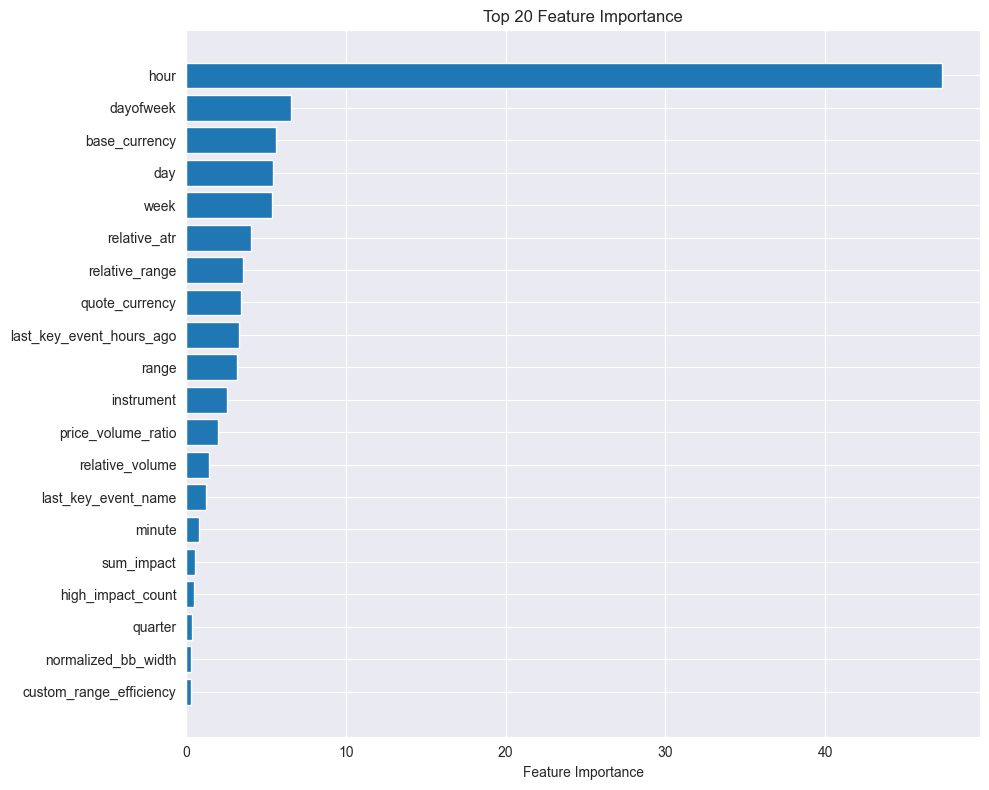

In [99]:
# Feature importance
feature_importance = final_model.get_feature_importance()
feature_names = X_processed.columns

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("Top 20 Most Important Features:")
print(importance_df.head(20).to_string(index=False))

# Plot feature importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
top_n = 20
top_features = importance_df.head(top_n)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Feature Importance')
plt.title(f'Top {top_n} Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

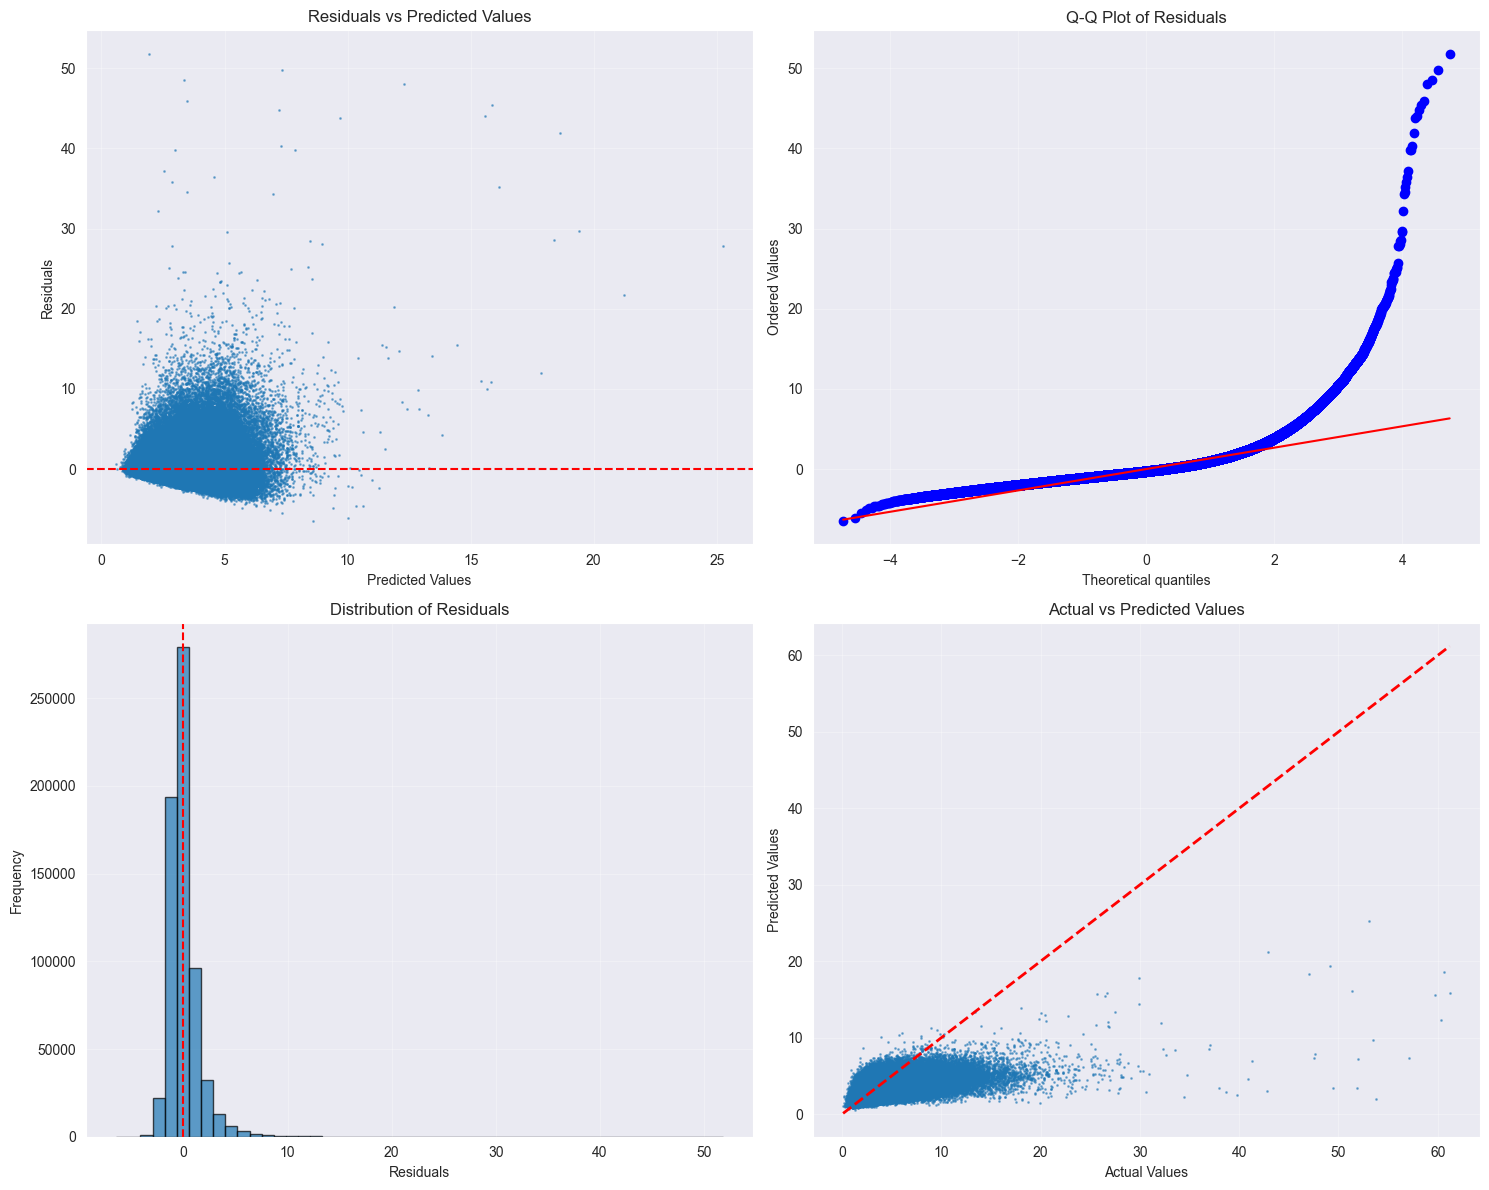

In [100]:
# Residual plots for model diagnostics
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Residuals vs Predicted
axes[0, 0].scatter(y_pred_final, residuals, alpha=0.5, s=1)
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_xlabel('Predicted Values')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Predicted Values')
axes[0, 0].grid(True, alpha=0.3)

# 2. Q-Q plot of residuals
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot of Residuals')
axes[0, 1].grid(True, alpha=0.3)

# 3. Distribution of residuals
axes[1, 0].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].axvline(x=0, color='r', linestyle='--')
axes[1, 0].set_xlabel('Residuals')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Residuals')
axes[1, 0].grid(True, alpha=0.3)

# 4. Actual vs Predicted
axes[1, 1].scatter(y, y_pred_final, alpha=0.5, s=1)
min_val = min(y.min(), y_pred_final.min())
max_val = max(y.max(), y_pred_final.max())
axes[1, 1].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
axes[1, 1].set_xlabel('Actual Values')
axes[1, 1].set_ylabel('Predicted Values')
axes[1, 1].set_title('Actual vs Predicted Values')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## RMSE (add prev range)

In [75]:
# Prepare data for CatBoost Regressor
# Drop datetime columns as they can't be used directly as features
X_processed = X.drop(['custom_event_time'], axis=1)

# Identify categorical features
categorical_features = ['dominant_event_type', 'last_key_event_name', 'instrument', 
                       'base_currency', 'quote_currency']
categorical_indices = [X_processed.columns.get_loc(col) for col in categorical_features if col in X_processed.columns]

print(f"Categorical features: {categorical_features}")
print(f"Categorical indices: {categorical_indices}")
print(f"\nX shape: {X_processed.shape}")
print(f"y shape: {y.shape}")
print(f"\nTarget statistics:")
print(y.describe())

Categorical features: ['dominant_event_type', 'last_key_event_name', 'instrument', 'base_currency', 'quote_currency']
Categorical indices: [6, 17, 19, 20, 21]

X shape: (650653, 40)
y shape: (650653,)

Target statistics:
count    650653.000000
mean          3.138687
std           1.874432
min           0.159703
25%           1.908771
50%           2.721515
75%           3.843046
max          61.200386
Name: target_range_normalized, dtype: float64


In [76]:
# Import regression metrics
from sklearn.metrics import (
    mean_absolute_error, 
    mean_squared_error, 
    root_mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
    median_absolute_error,
    explained_variance_score,
    max_error
)
import numpy as np

In [77]:
# TimeSeriesSplit for time series cross-validation
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

# Store results for each fold
fold_results = []

print(f"Starting TimeSeriesSplit cross-validation with {n_splits} folds...")
print("=" * 80)

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_processed), 1):
    print(f"\nFold {fold}/{n_splits}")
    print(f"Train size: {len(train_idx)}, Validation size: {len(val_idx)}")
    
    # Split data
    X_train, X_val = X_processed.iloc[train_idx], X_processed.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # Initialize CatBoost Regressor model
    model = CatBoostRegressor(
        iterations=1000,
        task_type="GPU",  # Uncomment if GPU available
        devices='0',
        learning_rate=0.1,
        depth=6,
        loss_function='RMSE',
        eval_metric='RMSE',
        random_seed=42,
        verbose=100,
        cat_features=categorical_indices,
        early_stopping_rounds=50
    )
    
    # Fit the model with validation set
    model.fit(
        X_train, y_train,
        eval_set=(X_val, y_val),
        cat_features=categorical_indices,
        use_best_model=True,
        plot=False
    )
    
    # Predictions on validation set
    y_val_pred = model.predict(X_val)
    
    # Calculate all regression metrics
    mae = mean_absolute_error(y_val, y_val_pred)
    mse = mean_squared_error(y_val, y_val_pred)
    rmse = root_mean_squared_error(y_val, y_val_pred)
    r2 = r2_score(y_val, y_val_pred)
    
    # MAPE (handle division by zero)
    try:
        mape = mean_absolute_percentage_error(y_val, y_val_pred)
    except:
        mape = np.mean(np.abs((y_val - y_val_pred) / (y_val + 1e-8))) * 100
    
    medae = median_absolute_error(y_val, y_val_pred)
    evs = explained_variance_score(y_val, y_val_pred)
    max_err = max_error(y_val, y_val_pred)
    
    # Additional metrics
    mean_abs_error = np.mean(np.abs(y_val - y_val_pred))
    std_error = np.std(y_val - y_val_pred)
    
    # Store results
    fold_results.append({
        'fold': fold,
        'mae': mae,
        'mse': mse,
        'rmse': rmse,
        'r2': r2,
        'mape': mape,
        'medae': medae,
        'explained_variance': evs,
        'max_error': max_err,
        'mean_abs_error': mean_abs_error,
        'std_error': std_error,
        'best_iteration': model.get_best_iteration()
    })
    
    print(f"\nValidation Metrics for Fold {fold}:")
    print(f"  MAE (Mean Absolute Error):        {mae:.6f}")
    print(f"  MSE (Mean Squared Error):          {mse:.6f}")
    print(f"  RMSE (Root Mean Squared Error):    {rmse:.6f}")
    print(f"  R² Score:                          {r2:.6f}")
    print(f"  MAPE (Mean Absolute % Error):      {mape:.4f}%")
    print(f"  MedAE (Median Absolute Error):     {medae:.6f}")
    print(f"  Explained Variance Score:          {evs:.6f}")
    print(f"  Max Error:                         {max_err:.6f}")
    print(f"  Mean Absolute Error:               {mean_abs_error:.6f}")
    print(f"  Std of Errors:                     {std_error:.6f}")
    print(f"  Best Iteration:                    {model.get_best_iteration()}")
    print("-" * 80)

Starting TimeSeriesSplit cross-validation with 5 folds...

Fold 1/5
Train size: 108443, Validation size: 108442
0:	learn: 1.7355554	test: 1.7404603	best: 1.7404603 (0)	total: 58.3ms	remaining: 58.2s
100:	learn: 1.4804118	test: 1.4607512	best: 1.4606721 (99)	total: 1.72s	remaining: 15.3s
200:	learn: 1.4361725	test: 1.4324477	best: 1.4324477 (200)	total: 3.4s	remaining: 13.5s
300:	learn: 1.4078390	test: 1.4191226	best: 1.4191226 (300)	total: 5.11s	remaining: 11.9s
400:	learn: 1.3868130	test: 1.4115500	best: 1.4101140 (390)	total: 6.8s	remaining: 10.2s
500:	learn: 1.3691650	test: 1.4076946	best: 1.4076946 (500)	total: 8.48s	remaining: 8.44s
600:	learn: 1.3532346	test: 1.4061369	best: 1.4060421 (593)	total: 10.1s	remaining: 6.73s
700:	learn: 1.3388477	test: 1.4040155	best: 1.4040155 (700)	total: 11.7s	remaining: 5.01s
800:	learn: 1.3249959	test: 1.4025023	best: 1.4025023 (800)	total: 13.4s	remaining: 3.33s
900:	learn: 1.3116124	test: 1.4014642	best: 1.4014585 (898)	total: 15.3s	remaining: 

In [78]:
# Summary of all folds
print("\n" + "=" * 80)
print("CROSS-VALIDATION SUMMARY")
print("=" * 80)

results_df = pd.DataFrame(fold_results)
print("\nMetrics per fold:")
print(results_df.to_string(index=False))

print("\nAverage metrics across all folds:")
print(f"  MAE:                  {results_df['mae'].mean():.6f} (+/- {results_df['mae'].std():.6f})")
print(f"  MSE:                  {results_df['mse'].mean():.6f} (+/- {results_df['mse'].std():.6f})")
print(f"  RMSE:                 {results_df['rmse'].mean():.6f} (+/- {results_df['rmse'].std():.6f})")
print(f"  R² Score:             {results_df['r2'].mean():.6f} (+/- {results_df['r2'].std():.6f})")
print(f"  MAPE:                 {results_df['mape'].mean():.4f}% (+/- {results_df['mape'].std():.4f}%)")
print(f"  MedAE:                {results_df['medae'].mean():.6f} (+/- {results_df['medae'].std():.6f})")
print(f"  Explained Variance:   {results_df['explained_variance'].mean():.6f} (+/- {results_df['explained_variance'].std():.6f})")
print(f"  Max Error:            {results_df['max_error'].mean():.6f} (+/- {results_df['max_error'].std():.6f})")
print(f"  Mean Abs Error:       {results_df['mean_abs_error'].mean():.6f} (+/- {results_df['mean_abs_error'].std():.6f})")
print(f"  Std of Errors:        {results_df['std_error'].mean():.6f} (+/- {results_df['std_error'].std():.6f})")
print(f"  Avg Best Iteration:   {results_df['best_iteration'].mean():.0f}")


CROSS-VALIDATION SUMMARY

Metrics per fold:
 fold      mae      mse     rmse       r2     mape    medae  explained_variance  max_error  mean_abs_error  std_error  best_iteration
    1 0.975964 1.960568 1.400203 0.365067 0.382725 0.758054            0.366479  30.609762        0.975964   1.398645             978
    2 0.949490 2.077502 1.441354 0.477387 0.363428 0.693570            0.479301  51.145856        0.949490   1.438712             999
    3 0.928521 1.848758 1.359690 0.442738 0.349176 0.703463            0.444320  37.249837        0.928521   1.357759             999
    4 0.999504 2.425901 1.557530 0.374777 0.366544 0.734755            0.374777  56.014467        0.999504   1.557529             517
    5 1.106170 2.733924 1.653458 0.256795 0.390980 0.824362            0.258174  58.408846        1.106170   1.651924             143

Average metrics across all folds:
  MAE:                  0.991930 (+/- 0.069255)
  MSE:                  2.209331 (+/- 0.364478)
  RMSE:             

In [79]:
# Train final model on all data
print("\n" + "=" * 80)
print("Training final model on all data...")
print("=" * 80)

final_model = CatBoostRegressor(
    iterations=1000,
    task_type="GPU",  # Uncomment if GPU available
    devices='0',
    learning_rate=0.1,
    depth=6,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    verbose=100,
    cat_features=categorical_indices
)

final_model.fit(X_processed, y, cat_features=categorical_indices)

# Final predictions on full dataset
y_pred_final = final_model.predict(X_processed)

# Final metrics
final_mae = mean_absolute_error(y, y_pred_final)
final_mse = mean_squared_error(y, y_pred_final)
final_rmse = root_mean_squared_error(y, y_pred_final)
final_r2 = r2_score(y, y_pred_final)

try:
    final_mape = mean_absolute_percentage_error(y, y_pred_final)
except:
    final_mape = np.mean(np.abs((y - y_pred_final) / (y + 1e-8))) * 100

final_medae = median_absolute_error(y, y_pred_final)
final_evs = explained_variance_score(y, y_pred_final)
final_max_err = max_error(y, y_pred_final)

print(f"\nFinal Model Metrics (on full dataset):")
print(f"  MAE:                  {final_mae:.6f}")
print(f"  MSE:                  {final_mse:.6f}")
print(f"  RMSE:                 {final_rmse:.6f}")
print(f"  R² Score:            {final_r2:.6f}")
print(f"  MAPE:                 {final_mape:.4f}%")
print(f"  MedAE:                {final_medae:.6f}")
print(f"  Explained Variance:  {final_evs:.6f}")
print(f"  Max Error:            {final_max_err:.6f}")

# Residual analysis
residuals = y - y_pred_final
print(f"\nResidual Statistics:")
print(f"  Mean of residuals:   {residuals.mean():.6f}")
print(f"  Std of residuals:    {residuals.std():.6f}")
print(f"  Min residual:        {residuals.min():.6f}")
print(f"  Max residual:        {residuals.max():.6f}")

print("\nModel training completed!")


Training final model on all data...
0:	learn: 1.8359191	total: 41.6ms	remaining: 41.5s
100:	learn: 1.4975636	total: 3.7s	remaining: 32.9s
200:	learn: 1.4609456	total: 7.38s	remaining: 29.3s
300:	learn: 1.4405913	total: 11.1s	remaining: 25.8s
400:	learn: 1.4257537	total: 14.8s	remaining: 22s
500:	learn: 1.4138914	total: 18.3s	remaining: 18.2s
600:	learn: 1.4046926	total: 21.9s	remaining: 14.5s
700:	learn: 1.3961119	total: 25.4s	remaining: 10.8s
800:	learn: 1.3884032	total: 29.1s	remaining: 7.22s
900:	learn: 1.3812024	total: 32.9s	remaining: 3.61s
999:	learn: 1.3755573	total: 36.5s	remaining: 0us

Final Model Metrics (on full dataset):
  MAE:                  0.922238
  MSE:                  1.891379
  RMSE:                 1.375274
  R² Score:            0.461681
  MAPE:                 0.3298%
  MedAE:                0.678475
  Explained Variance:  0.461682
  Max Error:            47.489227

Residual Statistics:
  Mean of residuals:   0.001921
  Std of residuals:    1.375274
  Min res

Top 20 Most Important Features:
                 feature  importance
                    hour   40.124342
   prev_5_max_range_norm   14.144067
            relative_atr    8.578037
               dayofweek    4.543298
          relative_range    4.115303
                     day    2.792618
                    week    2.638892
           base_currency    2.601603
        max_event_weight    2.536914
last_key_event_hours_ago    2.014773
                   range    1.726768
   prev_5_min_range_norm    1.589256
     dominant_event_type    1.415112
      price_volume_ratio    1.368402
 custom_range_efficiency    1.359210
          quote_currency    1.232251
              instrument    1.063178
  prev_5_mean_range_norm    1.019915
         relative_volume    0.878202
     normalized_bb_width    0.713863


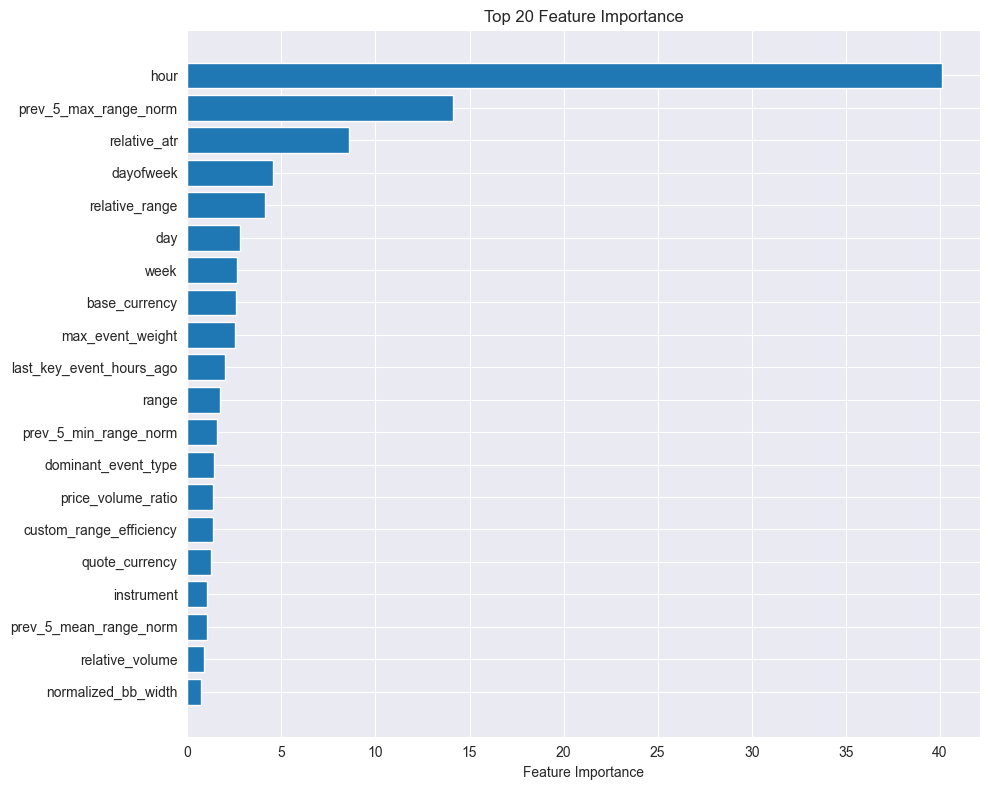

In [80]:
# Feature importance
feature_importance = final_model.get_feature_importance()
feature_names = X_processed.columns

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("Top 20 Most Important Features:")
print(importance_df.head(20).to_string(index=False))

# Plot feature importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
top_n = 20
top_features = importance_df.head(top_n)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Feature Importance')
plt.title(f'Top {top_n} Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

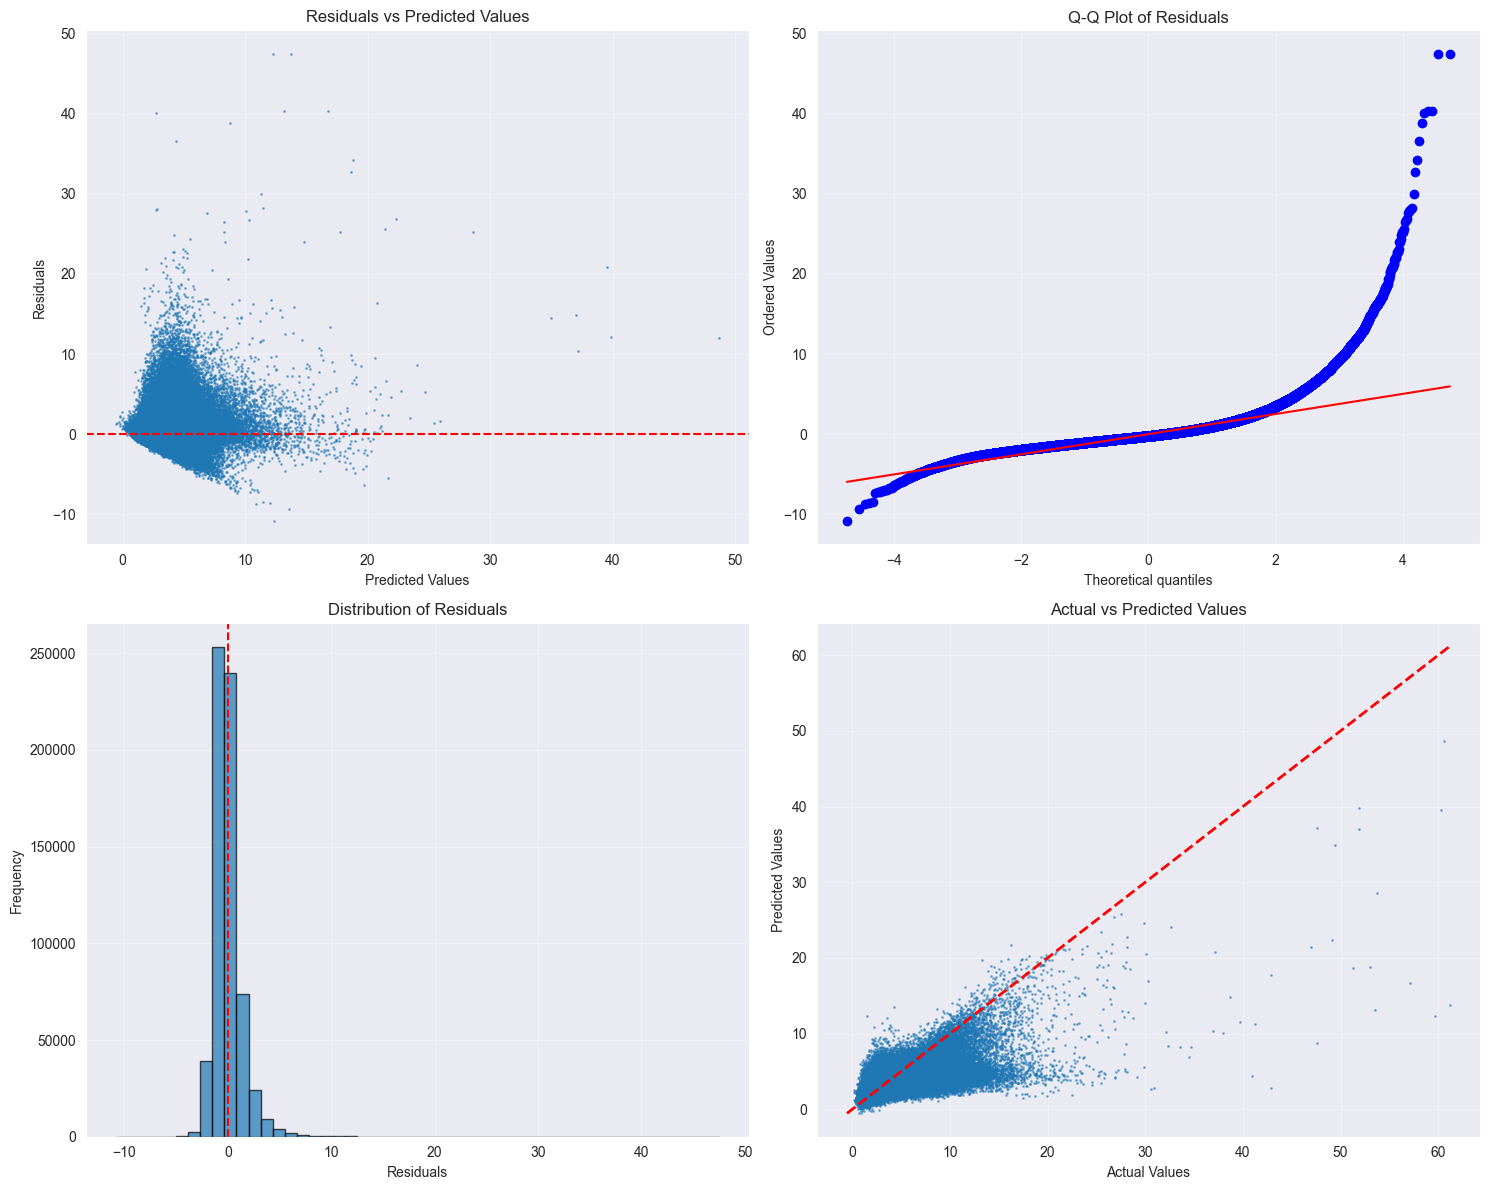

In [81]:
# Residual plots for model diagnostics
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Residuals vs Predicted
axes[0, 0].scatter(y_pred_final, residuals, alpha=0.5, s=1)
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_xlabel('Predicted Values')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Predicted Values')
axes[0, 0].grid(True, alpha=0.3)

# 2. Q-Q plot of residuals
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot of Residuals')
axes[0, 1].grid(True, alpha=0.3)

# 3. Distribution of residuals
axes[1, 0].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].axvline(x=0, color='r', linestyle='--')
axes[1, 0].set_xlabel('Residuals')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Residuals')
axes[1, 0].grid(True, alpha=0.3)

# 4. Actual vs Predicted
axes[1, 1].scatter(y, y_pred_final, alpha=0.5, s=1)
min_val = min(y.min(), y_pred_final.min())
max_val = max(y.max(), y_pred_final.max())
axes[1, 1].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
axes[1, 1].set_xlabel('Actual Values')
axes[1, 1].set_ylabel('Predicted Values')
axes[1, 1].set_title('Actual vs Predicted Values')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Quantile

In [101]:
# Prepare data for CatBoost Regressor
# Drop datetime columns as they can't be used directly as features
X_processed = X.drop(['custom_event_time'], axis=1)

# Identify categorical features
categorical_features = ['dominant_event_type', 'last_key_event_name', 'instrument', 
                       'base_currency', 'quote_currency']
categorical_indices = [X_processed.columns.get_loc(col) for col in categorical_features if col in X_processed.columns]

print(f"Categorical features: {categorical_features}")
print(f"Categorical indices: {categorical_indices}")
print(f"\nX shape: {X_processed.shape}")
print(f"y shape: {y.shape}")
print(f"\nTarget statistics:")
print(y.describe())

Categorical features: ['dominant_event_type', 'last_key_event_name', 'instrument', 'base_currency', 'quote_currency']
Categorical indices: [6, 17, 19, 20, 21]

X shape: (650774, 37)
y shape: (650774,)

Target statistics:
count    650774.000000
mean          3.138690
std           1.874367
min           0.096997
25%           1.908797
50%           2.721529
75%           3.843101
max          61.200386
Name: target_range_normalized, dtype: float64


In [102]:
# Import regression metrics
from sklearn.metrics import (
    mean_absolute_error, 
    mean_squared_error, 
    root_mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
    median_absolute_error,
    explained_variance_score,
    max_error
)
import numpy as np

In [104]:
# TimeSeriesSplit for time series cross-validation
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

# Store results for each fold
fold_results = []

print(f"Starting TimeSeriesSplit cross-validation with {n_splits} folds...")
print("=" * 80)

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_processed), 1):
    print(f"\nFold {fold}/{n_splits}")
    print(f"Train size: {len(train_idx)}, Validation size: {len(val_idx)}")
    
    # Split data
    X_train, X_val = X_processed.iloc[train_idx], X_processed.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    quantile = 0.5
    
    # Initialize CatBoost Regressor model
    model = CatBoostRegressor(
        iterations=1000,
        task_type="GPU",  # Uncomment if GPU available
        devices='0',
        learning_rate=0.05,
        depth=6,
        loss_function=f"Quantile:alpha={quantile}",
        eval_metric=f"Quantile:alpha={quantile}",
        random_seed=42,
        verbose=100,
        cat_features=categorical_indices,
        early_stopping_rounds=50
    )
    
    # Fit the model with validation set
    model.fit(
        X_train, y_train,
        eval_set=(X_val, y_val),
        cat_features=categorical_indices,
        use_best_model=True,
        plot=False
    )
    
    # Predictions on validation set
    y_val_pred = model.predict(X_val)
    
    # Calculate all regression metrics
    mae = mean_absolute_error(y_val, y_val_pred)
    mse = mean_squared_error(y_val, y_val_pred)
    rmse = root_mean_squared_error(y_val, y_val_pred)
    r2 = r2_score(y_val, y_val_pred)
    
    # MAPE (handle division by zero)
    try:
        mape = mean_absolute_percentage_error(y_val, y_val_pred)
    except:
        mape = np.mean(np.abs((y_val - y_val_pred) / (y_val + 1e-8))) * 100
    
    medae = median_absolute_error(y_val, y_val_pred)
    evs = explained_variance_score(y_val, y_val_pred)
    max_err = max_error(y_val, y_val_pred)
    
    # Additional metrics
    mean_abs_error = np.mean(np.abs(y_val - y_val_pred))
    std_error = np.std(y_val - y_val_pred)
    
    # Store results
    fold_results.append({
        'fold': fold,
        'mae': mae,
        'mse': mse,
        'rmse': rmse,
        'r2': r2,
        'mape': mape,
        'medae': medae,
        'explained_variance': evs,
        'max_error': max_err,
        'mean_abs_error': mean_abs_error,
        'std_error': std_error,
        'best_iteration': model.get_best_iteration()
    })
    
    print(f"\nValidation Metrics for Fold {fold}:")
    print(f"  MAE (Mean Absolute Error):        {mae:.6f}")
    print(f"  MSE (Mean Squared Error):          {mse:.6f}")
    print(f"  RMSE (Root Mean Squared Error):    {rmse:.6f}")
    print(f"  R² Score:                          {r2:.6f}")
    print(f"  MAPE (Mean Absolute % Error):      {mape:.4f}%")
    print(f"  MedAE (Median Absolute Error):     {medae:.6f}")
    print(f"  Explained Variance Score:          {evs:.6f}")
    print(f"  Max Error:                         {max_err:.6f}")
    print(f"  Mean Absolute Error:               {mean_abs_error:.6f}")
    print(f"  Std of Errors:                     {std_error:.6f}")
    print(f"  Best Iteration:                    {model.get_best_iteration()}")
    print("-" * 80)

Starting TimeSeriesSplit cross-validation with 5 folds...

Fold 1/5
Train size: 108464, Validation size: 108462
0:	learn: 0.5938433	test: 0.6607808	best: 0.6607808 (0)	total: 19.5ms	remaining: 19.5s
100:	learn: 0.4923496	test: 0.5559292	best: 0.5559292 (100)	total: 1.71s	remaining: 15.3s
200:	learn: 0.4800942	test: 0.5427789	best: 0.5427789 (200)	total: 3.48s	remaining: 13.8s
300:	learn: 0.4741237	test: 0.5376211	best: 0.5376211 (300)	total: 5.22s	remaining: 12.1s
400:	learn: 0.4695558	test: 0.5346112	best: 0.5346112 (400)	total: 6.97s	remaining: 10.4s
500:	learn: 0.4659891	test: 0.5325192	best: 0.5325192 (500)	total: 8.63s	remaining: 8.6s
600:	learn: 0.4632996	test: 0.5313247	best: 0.5313247 (600)	total: 10.2s	remaining: 6.8s
700:	learn: 0.4609120	test: 0.5304361	best: 0.5304361 (700)	total: 11.9s	remaining: 5.06s
800:	learn: 0.4585474	test: 0.5297107	best: 0.5297107 (800)	total: 13.5s	remaining: 3.36s
900:	learn: 0.4562048	test: 0.5290214	best: 0.5290211 (898)	total: 15.3s	remaining:

In [105]:
# Summary of all folds
print("\n" + "=" * 80)
print("CROSS-VALIDATION SUMMARY")
print("=" * 80)

results_df = pd.DataFrame(fold_results)
print("\nMetrics per fold:")
print(results_df.to_string(index=False))

print("\nAverage metrics across all folds:")
print(f"  MAE:                  {results_df['mae'].mean():.6f} (+/- {results_df['mae'].std():.6f})")
print(f"  MSE:                  {results_df['mse'].mean():.6f} (+/- {results_df['mse'].std():.6f})")
print(f"  RMSE:                 {results_df['rmse'].mean():.6f} (+/- {results_df['rmse'].std():.6f})")
print(f"  R² Score:             {results_df['r2'].mean():.6f} (+/- {results_df['r2'].std():.6f})")
print(f"  MAPE:                 {results_df['mape'].mean():.4f}% (+/- {results_df['mape'].std():.4f}%)")
print(f"  MedAE:                {results_df['medae'].mean():.6f} (+/- {results_df['medae'].std():.6f})")
print(f"  Explained Variance:   {results_df['explained_variance'].mean():.6f} (+/- {results_df['explained_variance'].std():.6f})")
print(f"  Max Error:            {results_df['max_error'].mean():.6f} (+/- {results_df['max_error'].std():.6f})")
print(f"  Mean Abs Error:       {results_df['mean_abs_error'].mean():.6f} (+/- {results_df['mean_abs_error'].std():.6f})")
print(f"  Std of Errors:        {results_df['std_error'].mean():.6f} (+/- {results_df['std_error'].std():.6f})")
print(f"  Avg Best Iteration:   {results_df['best_iteration'].mean():.0f}")


CROSS-VALIDATION SUMMARY

Metrics per fold:
 fold      mae      mse     rmse       r2     mape    medae  explained_variance  max_error  mean_abs_error  std_error  best_iteration
    1 1.057082 3.200544 1.789006 0.222940 0.328688 0.660541            0.264565  27.598160        1.057082   1.740432             998
    2 1.016180 2.934135 1.712932 0.210409 0.318894 0.664703            0.243748  52.404743        1.016180   1.676379             998
    3 0.991444 2.579273 1.606012 0.239407 0.308867 0.645229            0.278331  31.544331        0.991444   1.564378             999
    4 0.907644 1.982169 1.407895 0.286081 0.290145 0.620007            0.321984  26.054590        0.907644   1.372037             999
    5 1.027667 2.980580 1.726436 0.224860 0.303231 0.652020            0.273390  56.038293        1.027667   1.671518             999

Average metrics across all folds:
  MAE:                  1.000003 (+/- 0.056764)
  MSE:                  2.735340 (+/- 0.476367)
  RMSE:             

In [106]:
# Train final model on all data
print("\n" + "=" * 80)
print("Training final model on all data...")
print("=" * 80)

final_model = CatBoostRegressor(
    iterations=1000,
    task_type="GPU",  # Uncomment if GPU available
    devices='0',
    learning_rate=0.05,
    depth=6,
    loss_function=f"Quantile:alpha={quantile}",
    eval_metric=f"Quantile:alpha={quantile}",
    random_seed=42,
    verbose=100,
    cat_features=categorical_indices
)

final_model.fit(X_processed, y, cat_features=categorical_indices)

# Final predictions on full dataset
y_pred_final = final_model.predict(X_processed)

# Final metrics
final_mae = mean_absolute_error(y, y_pred_final)
final_mse = mean_squared_error(y, y_pred_final)
final_rmse = root_mean_squared_error(y, y_pred_final)
final_r2 = r2_score(y, y_pred_final)

try:
    final_mape = mean_absolute_percentage_error(y, y_pred_final)
except:
    final_mape = np.mean(np.abs((y - y_pred_final) / (y + 1e-8))) * 100

final_medae = median_absolute_error(y, y_pred_final)
final_evs = explained_variance_score(y, y_pred_final)
final_max_err = max_error(y, y_pred_final)

print(f"\nFinal Model Metrics (on full dataset):")
print(f"  MAE:                  {final_mae:.6f}")
print(f"  MSE:                  {final_mse:.6f}")
print(f"  RMSE:                 {final_rmse:.6f}")
print(f"  R² Score:            {final_r2:.6f}")
print(f"  MAPE:                 {final_mape:.4f}%")
print(f"  MedAE:                {final_medae:.6f}")
print(f"  Explained Variance:  {final_evs:.6f}")
print(f"  Max Error:            {final_max_err:.6f}")

# Residual analysis
residuals = y - y_pred_final
print(f"\nResidual Statistics:")
print(f"  Mean of residuals:   {residuals.mean():.6f}")
print(f"  Std of residuals:    {residuals.std():.6f}")
print(f"  Min residual:        {residuals.min():.6f}")
print(f"  Max residual:        {residuals.max():.6f}")

print("\nModel training completed!")


Training final model on all data...
0:	learn: 0.6281394	total: 36.1ms	remaining: 36s
100:	learn: 0.5211560	total: 3.65s	remaining: 32.5s
200:	learn: 0.5083190	total: 7.31s	remaining: 29.1s
300:	learn: 0.5022650	total: 11.1s	remaining: 25.7s
400:	learn: 0.4984528	total: 14.7s	remaining: 21.9s
500:	learn: 0.4957341	total: 18.4s	remaining: 18.3s
600:	learn: 0.4936127	total: 22.1s	remaining: 14.7s
700:	learn: 0.4918141	total: 25.9s	remaining: 11s
800:	learn: 0.4902761	total: 29.5s	remaining: 7.34s
900:	learn: 0.4890854	total: 33.2s	remaining: 3.65s
999:	learn: 0.4880570	total: 36.9s	remaining: 0us

Final Model Metrics (on full dataset):
  MAE:                  0.975893
  MSE:                  2.630194
  RMSE:                 1.621787
  R² Score:            0.251349
  MAPE:                 0.3036%
  MedAE:                0.630979
  Explained Variance:  0.287150
  Max Error:            58.739666

Residual Statistics:
  Mean of residuals:   0.354650
  Std of residuals:    1.582536
  Min resi

Top 20 Most Important Features:
                 feature  importance
                    hour   63.372746
           base_currency    7.741311
          quote_currency    4.415859
               dayofweek    3.914459
          relative_range    3.894154
            relative_atr    3.148923
              instrument    2.829661
                   range    2.655753
                    week    2.306760
      price_volume_ratio    1.545757
         relative_volume    1.327813
                     day    1.081369
                  minute    0.475430
last_key_event_hours_ago    0.320801
     normalized_bb_width    0.161316
              wick_ratio    0.133685
              sum_impact    0.133034
              news_count    0.090887
kaufman_efficiency_ratio    0.084165
                 quarter    0.063342


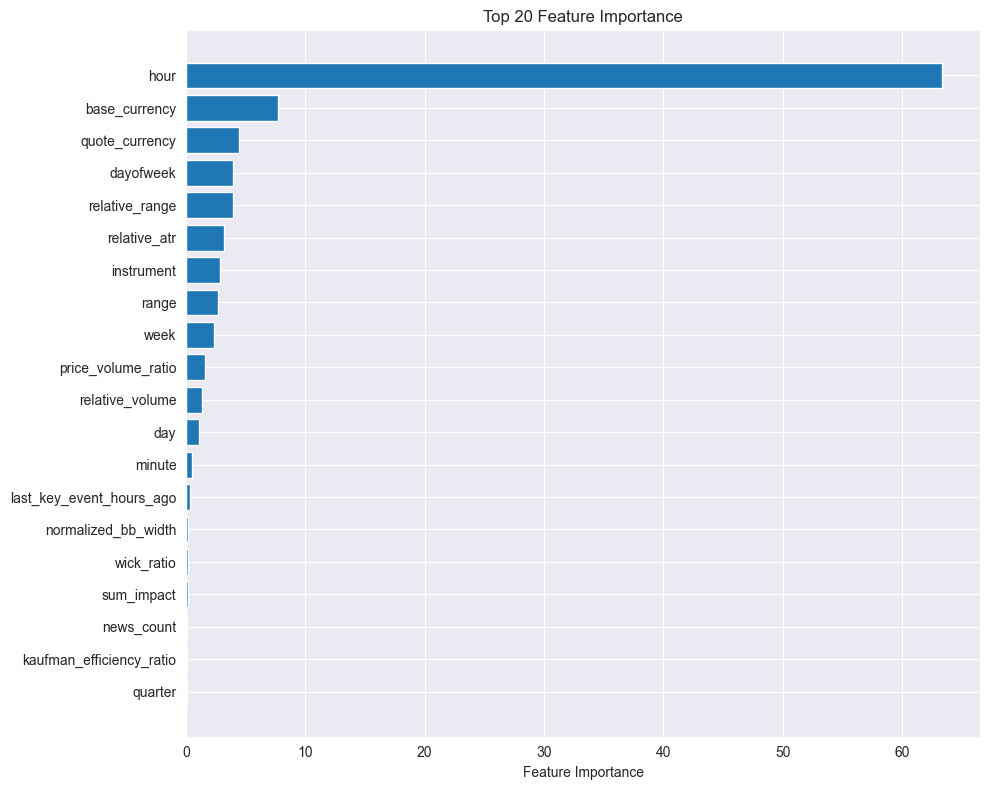

In [107]:
# Feature importance
feature_importance = final_model.get_feature_importance()
feature_names = X_processed.columns

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("Top 20 Most Important Features:")
print(importance_df.head(20).to_string(index=False))

# Plot feature importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
top_n = 20
top_features = importance_df.head(top_n)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Feature Importance')
plt.title(f'Top {top_n} Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

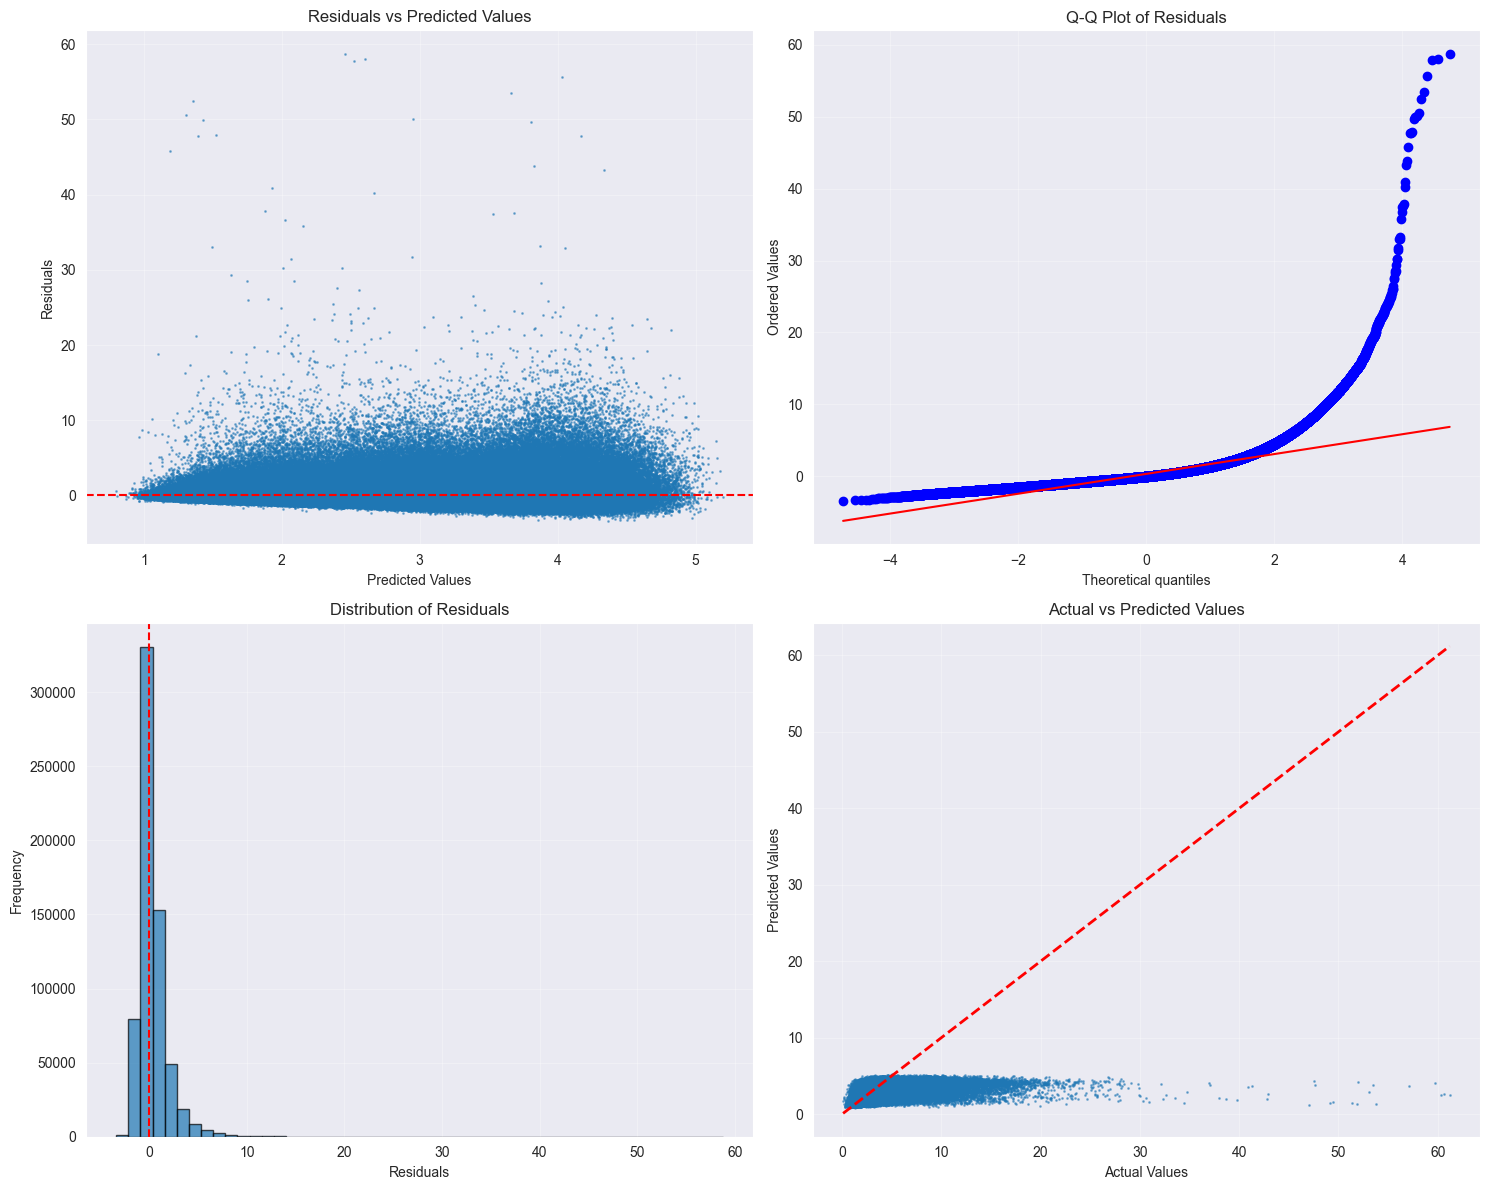

In [108]:
# Residual plots for model diagnostics
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Residuals vs Predicted
axes[0, 0].scatter(y_pred_final, residuals, alpha=0.5, s=1)
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_xlabel('Predicted Values')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Predicted Values')
axes[0, 0].grid(True, alpha=0.3)

# 2. Q-Q plot of residuals
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot of Residuals')
axes[0, 1].grid(True, alpha=0.3)

# 3. Distribution of residuals
axes[1, 0].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].axvline(x=0, color='r', linestyle='--')
axes[1, 0].set_xlabel('Residuals')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Residuals')
axes[1, 0].grid(True, alpha=0.3)

# 4. Actual vs Predicted
axes[1, 1].scatter(y, y_pred_final, alpha=0.5, s=1)
min_val = min(y.min(), y_pred_final.min())
max_val = max(y.max(), y_pred_final.max())
axes[1, 1].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
axes[1, 1].set_xlabel('Actual Values')
axes[1, 1].set_ylabel('Predicted Values')
axes[1, 1].set_title('Actual vs Predicted Values')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()